<a href="https://colab.research.google.com/github/djsmacker01/AI-Python/blob/main/Mod1_AI_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:linear-gradient(135deg,#0D1B3E 0%,#1A3A6B 100%);padding:45px;border-radius:14px;color:white;text-align:center;margin-bottom:24px;">
  <div style="font-size:3em;margin-bottom:10px;">🏥</div>
  <h1 style="color:#009B8D;font-size:2em;margin:0;">Imperial College Business School</h1>
  <h2 style="color:white;font-size:1.5em;margin:10px 0;">Professional Certificate in Machine Learning &amp; AI</h2>
  <h3 style="color:#8EACC8;font-weight:normal;font-size:1.15em;margin:0;">Module 01 — Mathematical Foundations Through the Lens of Healthcare</h3>
  <div style="margin-top:18px;padding:12px 24px;background:rgba(0,155,141,0.18);border-radius:8px;display:inline-block;">
    <span style="color:#009B8D;font-weight:bold;">Hasan Adil</span>
    <span style="color:#8EACC8;"> · Lead Data Analyst, Healthcare · Learning Facilitator</span>
  </div>
</div>

---

## 🩺 Why Healthcare?

Healthcare is one of the most data-rich, highest-stakes domains for AI. Every concept in this module — linear algebra, calculus, probability, optimisation — is actively deployed in hospitals, diagnostic labs, pharmaceutical companies, and health systems **right now**.

By the end of this notebook you will be able to say:

| Concept | Healthcare Application You Will Build |
|---|---|
| 📐 **Linear Algebra** | Patient record similarity · MRI image storage · Genomic data compression |
| 📈 **Calculus & Gradient Descent** | Diabetic retinopathy detector · Drug dosage optimiser |
| 🎲 **Probability & Statistics** | Cancer screening model · ICU readmission risk · Clinical trial analysis |
| ⚙️ **Optimisation** | Hospital bed scheduling · Treatment plan selector · NHS resource allocation |

---

## 📖 How to Use This Notebook

- **Run a cell:** Click it → `Shift + Enter`
- **Run everything:** `Kernel → Restart & Run All`
- Look for 💡 **Try This** prompts — they invite you to experiment
- Every section ends with a **Clinical Takeaway** grounding the maths in real practice


In [1]:
# ═══════════════════════════════════════════════════════════════════
#  SETUP — run this cell first before anything else
# ═══════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyArrowPatch
import scipy.stats as stats
from scipy.signal import argrelmin
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)
from sklearn.datasets import make_classification
import warnings
warnings.filterwarnings('ignore')

# ── Imperial + Healthcare colour palette ────────────────────────────
IMP_NAVY   = '#0D1B3E'
IMP_TEAL   = '#009B8D'
C_LA       = '#1A6FB5'   # Linear Algebra  — blue
C_CA       = '#C85E10'   # Calculus        — orange
C_PR       = '#7A38B8'   # Probability     — purple
C_OP       = '#0A8A5A'   # Optimisation    — green
C_ALERT    = '#D62728'   # Clinical alert  — red
C_SAFE     = '#2CA02C'   # Safe / normal   — green
C_WARN     = '#FF7F0E'   # Warning         — amber
GREY_BG    = '#F4F7FA'

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : GREY_BG,
    'axes.grid'        : True,
    'grid.alpha'       : 0.35,
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.labelcolor'  : IMP_NAVY,
    'xtick.color'      : IMP_NAVY,
    'ytick.color'      : IMP_NAVY,
})

np.random.seed(42)
print('✅  Healthcare ML notebook ready!')
print('    Packages: NumPy, Pandas, Matplotlib, SciPy, Scikit-learn')
print('    All clinical examples use anonymised synthetic data.')

✅  Healthcare ML notebook ready!
    Packages: NumPy, Pandas, Matplotlib, SciPy, Scikit-learn
    All clinical examples use anonymised synthetic data.


---
<div style="background:#1A6FB5;padding:22px 28px;border-radius:12px;color:white;">
  <h1 style="margin:0;font-size:1.8em;">📐 Part 1: Linear Algebra</h1>
  <p style="margin:8px 0 0 0;font-size:1.05em;opacity:0.9;">Matrices · Vectors · Dot Products · Eigenvectors · Tensors</p>
</div>

### 💡 The Big Idea
> In healthcare, every piece of data — a blood test result, an MRI scan, a patient's drug history, a genome — is stored as **a grid or list of numbers**. Linear algebra is the mathematical toolkit that lets AI read, compare, transform, and compress those grids at scale.

### 🏥 Healthcare Applications
- **Patient similarity matching** — finding the most similar past patient to guide treatment
- **Medical imaging** — MRI, CT, and X-ray are all matrices/tensors
- **Genomics** — a patient's full genome is a vector of ~3 billion values
- **Electronic Health Records (EHR)** — each patient is a row in a matrix


<div style="background:#EAF3FB;border-left:5px solid #1A6FB5;padding:20px;border-radius:8px;margin:16px 0;">
<h2 style="color:#1A6FB5;margin-top:0;">🔢 Mathematical Deep-Dive: Vectors</h2>

### What is a Vector?

A **vector** is an ordered list of numbers arranged in a column (or row). In machine learning every data point — a patient's blood results, a pixel, a word — is represented as a vector.

$$\mathbf{v} = \begin{pmatrix} v_1 \\ v_2 \\ \vdots \\ v_n \end{pmatrix} \in \mathbb{R}^n$$

### Vector Operations — Step by Step

**1. Vector Addition** — add element by element:

$$\mathbf{a} + \mathbf{b} = \begin{pmatrix}3\\1\\4\end{pmatrix} + \begin{pmatrix}1\\5\\9\end{pmatrix} = \begin{pmatrix}3+1\\1+5\\4+9\end{pmatrix} = \begin{pmatrix}4\\6\\13\end{pmatrix}$$

**2. Scalar Multiplication** — multiply every element by a constant $c$:

$$2 \cdot \begin{pmatrix}3\\1\\4\end{pmatrix} = \begin{pmatrix}6\\2\\8\end{pmatrix}$$

**3. Vector Norm (Magnitude)** — the "length" of a vector in $n$-dimensional space:

$$\|\mathbf{v}\| = \sqrt{v_1^2 + v_2^2 + \cdots + v_n^2}$$

*Worked example* — patient's HbA1c, Glucose, BP as a 3D vector $\mathbf{p} = (7.8,\ 9.2,\ 14.0)$:

$$\|\mathbf{p}\| = \sqrt{7.8^2 + 9.2^2 + 14.0^2} = \sqrt{60.84 + 84.64 + 196.00} = \sqrt{341.48} \approx 18.48$$

**4. Unit Vector** — a vector rescaled to have length 1 (used in cosine similarity):

$$\hat{\mathbf{v}} = \frac{\mathbf{v}}{\|\mathbf{v}\|}, \qquad \|\hat{\mathbf{v}}\| = 1$$

### Why Does This Matter in ML?

Every patient in an EHR becomes a point in $\mathbb{R}^n$. Patients who are clinically similar live **close together** in this space. The entire science of distance-based ML (KNN, clustering, embeddings) rests on these four operations.
</div>


In [2]:
# ── WORKED MATHS: Vector operations step by step ────────────────────────────
import numpy as np

print("=" * 60)
print("  VECTOR MATHEMATICS — Step-by-Step Numerical Verification")
print("=" * 60)

# ── Define two patient vectors (HbA1c, Glucose, SystolicBP)
a = np.array([7.8, 9.2, 14.0])   # Patient A
b = np.array([8.9, 11.5, 15.5])  # Patient B

# 1. Vector addition
print("\n1. VECTOR ADDITION:  a + b")
for i, (ai, bi) in enumerate(zip(a, b)):
    print(f"   feature[{i}]: {ai} + {bi} = {ai+bi}")
print(f"   Result: {a + b}")

# 2. Scalar multiplication
c = 2.0
print(f"\n2. SCALAR MULTIPLICATION:  {c} × a")
for i, ai in enumerate(a):
    print(f"   feature[{i}]: {c} × {ai} = {c*ai}")
print(f"   Result: {c * a}")

# 3. Vector norm
norm_a = np.sqrt(np.sum(a**2))
print(f"\n3. VECTOR NORM:  ||a|| = sqrt({' + '.join([f'{x:.2f}^2' for x in a])})")
print(f"   = sqrt({' + '.join([f'{x**2:.2f}' for x in a])})")
print(f"   = sqrt({sum(a**2):.2f}) = {norm_a:.4f}")
print(f"   NumPy check: {np.linalg.norm(a):.4f}")

# 4. Unit vector
a_hat = a / norm_a
print(f"\n4. UNIT VECTOR:  â = a / ||a||")
print(f"   = {a} / {norm_a:.4f}")
print(f"   = {a_hat.round(4)}")
print(f"   Verify ||â|| = {np.linalg.norm(a_hat):.6f}  (should be 1.0)")


  VECTOR MATHEMATICS — Step-by-Step Numerical Verification

1. VECTOR ADDITION:  a + b
   feature[0]: 7.8 + 8.9 = 16.7
   feature[1]: 9.2 + 11.5 = 20.7
   feature[2]: 14.0 + 15.5 = 29.5
   Result: [16.7 20.7 29.5]

2. SCALAR MULTIPLICATION:  2.0 × a
   feature[0]: 2.0 × 7.8 = 15.6
   feature[1]: 2.0 × 9.2 = 18.4
   feature[2]: 2.0 × 14.0 = 28.0
   Result: [15.6 18.4 28. ]

3. VECTOR NORM:  ||a|| = sqrt(7.80^2 + 9.20^2 + 14.00^2)
   = sqrt(60.84 + 84.64 + 196.00)
   = sqrt(341.48) = 18.4792
   NumPy check: 18.4792

4. UNIT VECTOR:  â = a / ||a||
   = [ 7.8  9.2 14. ] / 18.4792
   = [0.4221 0.4979 0.7576]
   Verify ||â|| = 1.000000  (should be 1.0)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  1.1  VECTORS — Every Patient Is a Vector of Numbers
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


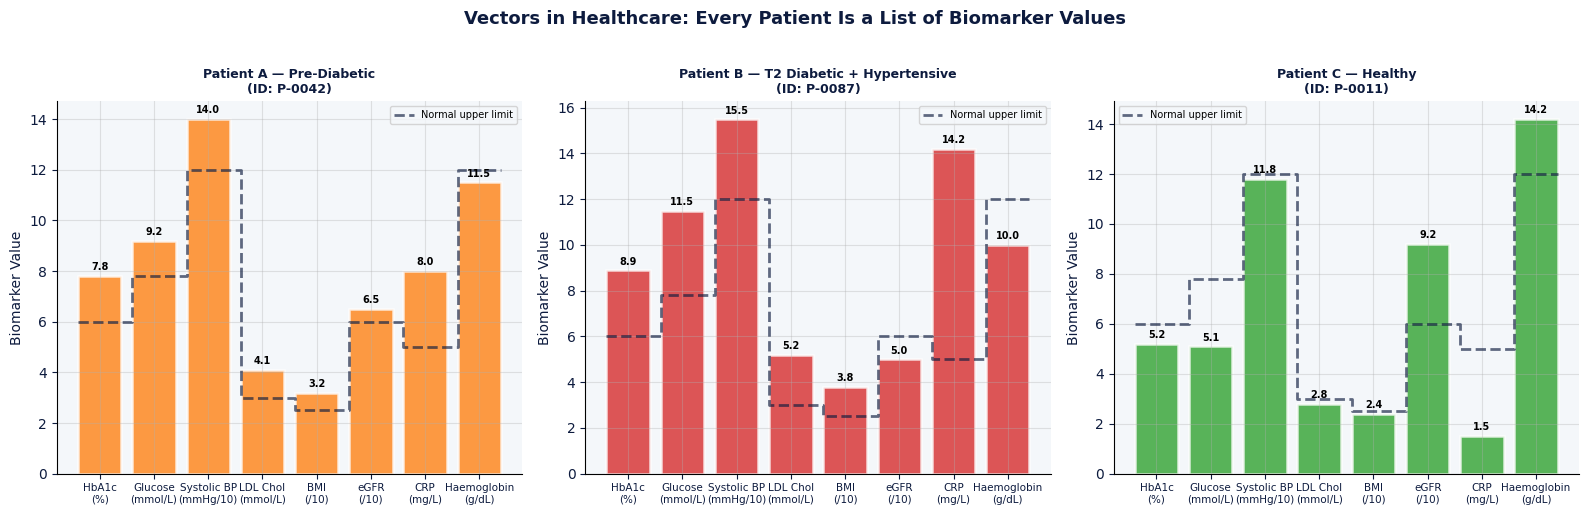

Patient A vector shape: (8,)  → 8 biomarkers
Patient A: [ 7.8  9.2 14.   4.1  3.2  6.5  8.  11.5]
Patient B: [ 8.9 11.5 15.5  5.2  3.8  5.  14.2 10. ]
Patient C: [ 5.2  5.1 11.8  2.8  2.4  9.2  1.5 14.2]

💡 In a real EHR, a patient vector might have 500–10,000 dimensions:
   lab results, medications, diagnoses, procedures, vital signs...
   Linear algebra lets AI process all of them simultaneously.


In [3]:
# ═══════════════════════════════════════════════════════════════════
#  1.1  VECTORS — Patient Lab Results as Feature Vectors
# ═══════════════════════════════════════════════════════════════════
print("━" * 62)
print("  1.1  VECTORS — Every Patient Is a Vector of Numbers")
print("━" * 62)

# A patient's blood panel — each number is one biomarker
# Features: [HbA1c, Glucose, Systolic BP, LDL Cholesterol,
#            BMI, eGFR (kidney), CRP (inflammation), Haemoglobin]
feature_names = ['HbA1c\n(%)', 'Glucose\n(mmol/L)', 'Systolic BP\n(mmHg/10)',
                 'LDL Chol\n(mmol/L)', 'BMI\n(/10)', 'eGFR\n(/10)',
                 'CRP\n(mg/L)', 'Haemoglobin\n(g/dL)']

# Three patients — synthetic but clinically plausible
patient_A = np.array([7.8, 9.2, 14.0, 4.1, 3.2, 6.5, 8.0, 11.5])  # Pre-diabetic
patient_B = np.array([8.9, 11.5, 15.5, 5.2, 3.8, 5.0, 14.2, 10.0]) # T2 Diabetic + hypertensive
patient_C = np.array([5.2,  5.1, 11.8, 2.8, 2.4, 9.2,  1.5, 14.2]) # Healthy

# Reference normal ranges (upper bound for visualisation)
normal_upper = np.array([6.0, 7.8, 12.0, 3.0, 2.5, 6.0, 5.0, 12.0])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Vectors in Healthcare: Every Patient Is a List of Biomarker Values',
             fontsize=13, fontweight='bold', color=IMP_NAVY, y=1.02)

patients = [
    (patient_A, 'Patient A — Pre-Diabetic\n(ID: P-0042)', C_WARN),
    (patient_B, 'Patient B — T2 Diabetic + Hypertensive\n(ID: P-0087)', C_ALERT),
    (patient_C, 'Patient C — Healthy\n(ID: P-0011)', C_SAFE),
]

x = np.arange(len(feature_names))
for ax, (pat, title, col) in zip(axes, patients):
    bars = ax.bar(x, pat, color=col, alpha=0.78, edgecolor='white', linewidth=1.8)
    ax.step(np.append(x - 0.4, x[-1] + 0.4),
            np.append(normal_upper, normal_upper[-1]),
            where='post', color=IMP_NAVY, linewidth=2,
            linestyle='--', alpha=0.65, label='Normal upper limit')
    ax.set_xticks(x)
    ax.set_xticklabels(feature_names, fontsize=7.5)
    ax.set_title(title, fontweight='bold', color=IMP_NAVY, fontsize=9)
    ax.set_ylabel('Biomarker Value')
    ax.legend(fontsize=7)
    for bar, val in zip(bars, pat):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                f'{val}', ha='center', va='bottom', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Patient A vector shape: {patient_A.shape}  → 8 biomarkers")
print(f"Patient A: {patient_A}")
print(f"Patient B: {patient_B}")
print(f"Patient C: {patient_C}")
print()
print("💡 In a real EHR, a patient vector might have 500–10,000 dimensions:")
print("   lab results, medications, diagnoses, procedures, vital signs...")
print("   Linear algebra lets AI process all of them simultaneously.")


<div style="background:#EAF3FB;border-left:5px solid #1A6FB5;padding:20px;border-radius:8px;margin:16px 0;">
<h2 style="color:#1A6FB5;margin-top:0;">🔢 Mathematical Deep-Dive: Dot Products & Cosine Similarity</h2>

### The Dot Product — Step by Step

Given two vectors $\mathbf{a}, \mathbf{b} \in \mathbb{R}^n$, the **dot product** (also called inner product) is:

$$\mathbf{a} \cdot \mathbf{b} = \sum_{i=1}^{n} a_i b_i = a_1 b_1 + a_2 b_2 + \cdots + a_n b_n$$

**Worked Example — Two patient biomarker vectors:**

$$\mathbf{p_A} = (7.8,\ 9.2,\ 14.0), \quad \mathbf{p_B} = (8.9,\ 11.5,\ 15.5)$$

$$\mathbf{p_A} \cdot \mathbf{p_B} = (7.8 \times 8.9) + (9.2 \times 11.5) + (14.0 \times 15.5)$$

$$= 69.42 + 105.80 + 217.00 = 392.22$$

### Geometric Interpretation

The dot product equals:

$$\mathbf{a} \cdot \mathbf{b} = \|\mathbf{a}\| \cdot \|\mathbf{b}\| \cdot \cos\theta$$

where $\theta$ is the **angle between the two vectors**.

- If $\theta = 0°$: vectors point the same direction → $\cos 0 = 1$ → **maximum similarity**
- If $\theta = 90°$: vectors are perpendicular → $\cos 90 = 0$ → **no similarity**
- If $\theta = 180°$: vectors point opposite directions → $\cos 180 = -1$ → **opposite**

### Cosine Similarity — The Clinical Matching Formula

Rearranging the geometric form, isolating $\cos\theta$:

$$\text{cosine\_similarity}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \cdot \|\mathbf{b}\|}$$

**Full step-by-step for our two patients:**

$$\|\mathbf{p_A}\| = \sqrt{7.8^2 + 9.2^2 + 14.0^2} = \sqrt{341.48} = 18.48$$

$$\|\mathbf{p_B}\| = \sqrt{8.9^2 + 11.5^2 + 15.5^2} = \sqrt{79.21 + 132.25 + 240.25} = \sqrt{451.71} = 21.25$$

$$\text{cosine\_similarity} = \frac{392.22}{18.48 \times 21.25} = \frac{392.22}{392.70} \approx 0.9988$$

**Interpretation:** A score of $0.9988$ (very close to $1.0$) means these two patients are clinically almost identical — Patient B is Patient A's nearest neighbour in biomarker space.
</div>


In [ ]:
# ── WORKED MATHS: Dot product and cosine similarity ─────────────────────────
import numpy as np

print("=" * 60)
print("  DOT PRODUCT & COSINE SIMILARITY — Full Derivation")
print("=" * 60)

a = np.array([7.8, 9.2, 14.0])    # Patient A
b = np.array([8.9, 11.5, 15.5])   # Patient B (similar)
c = np.array([5.2,  5.1, 11.8])   # Patient C (healthy, different)

feat = ['HbA1c', 'Glucose', 'BP']

for name, vec, label in [('B (similar)', b, 'b'), ('C (different)', c, 'c')]:
    print(f"\n── Dot product:  a · {label} ──────────────────────────────")
    total = 0
    for f, ai, xi in zip(feat, a, vec):
        prod = ai * xi
        total += prod
        print(f"   {f:<10}: {ai:.1f} × {xi:.1f} = {prod:.3f}")
    print(f"   Sum = {total:.3f}   (numpy: {np.dot(a, vec):.3f})")

    norm_a = np.linalg.norm(a)
    norm_v = np.linalg.norm(vec)
    cos_sim = np.dot(a, vec) / (norm_a * norm_v)
    theta   = np.degrees(np.arccos(cos_sim))

    print(f"\n── Cosine similarity ──────────────────────────────────────")
    print(f"   ||a||  = {norm_a:.4f}")
    print(f"   ||{label}||  = {norm_v:.4f}")
    print(f"   cos(θ) = {total:.3f} / ({norm_a:.4f} × {norm_v:.4f})")
    print(f"         = {total:.3f} / {norm_a * norm_v:.4f}")
    print(f"         = {cos_sim:.4f}")
    print(f"   θ      = arccos({cos_sim:.4f}) = {theta:.2f}°")
    print(f"   Patient {name}: similarity = {cos_sim:.4f}, angle = {theta:.1f}°")

print("\nConclusion: Patient B is much closer to A (higher similarity,")
print("smaller angle) than Patient C — exactly what the clinical picture suggests.")

  DOT PRODUCT & COSINE SIMILARITY — Full Derivation

── Dot product:  a · b ──────────────────────────────
   HbA1c     : 7.8 × 8.9 = 69.420
   Glucose   : 9.2 × 11.5 = 105.800
   BP        : 14.0 × 15.5 = 217.000
   Sum = 392.220   (numpy: 392.220)

── Cosine similarity ──────────────────────────────────────
   ||a||  = 18.4792
   ||b||  = 21.2535
   cos(θ) = 392.220 / (18.4792 × 21.2535)
         = 392.220 / 392.7466
         = 0.9987
   θ      = arccos(0.9987) = 2.97°
   Patient B (similar): similarity = 0.9987, angle = 3.0°

── Dot product:  a · c ──────────────────────────────
   HbA1c     : 7.8 × 5.2 = 40.560
   Glucose   : 9.2 × 5.1 = 46.920
   BP        : 14.0 × 11.8 = 165.200
   Sum = 252.680   (numpy: 252.680)

── Cosine similarity ──────────────────────────────────────
   ||a||  = 18.4792
   ||c||  = 13.8669
   cos(θ) = 252.680 / (18.4792 × 13.8669)
         = 252.680 / 256.2483
         = 0.9861
   θ      = arccos(0.9861) = 9.57°
   Patient C (different): similarity = 0.986

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  1.2  DOT PRODUCTS — 'Find me the most similar past patient'
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


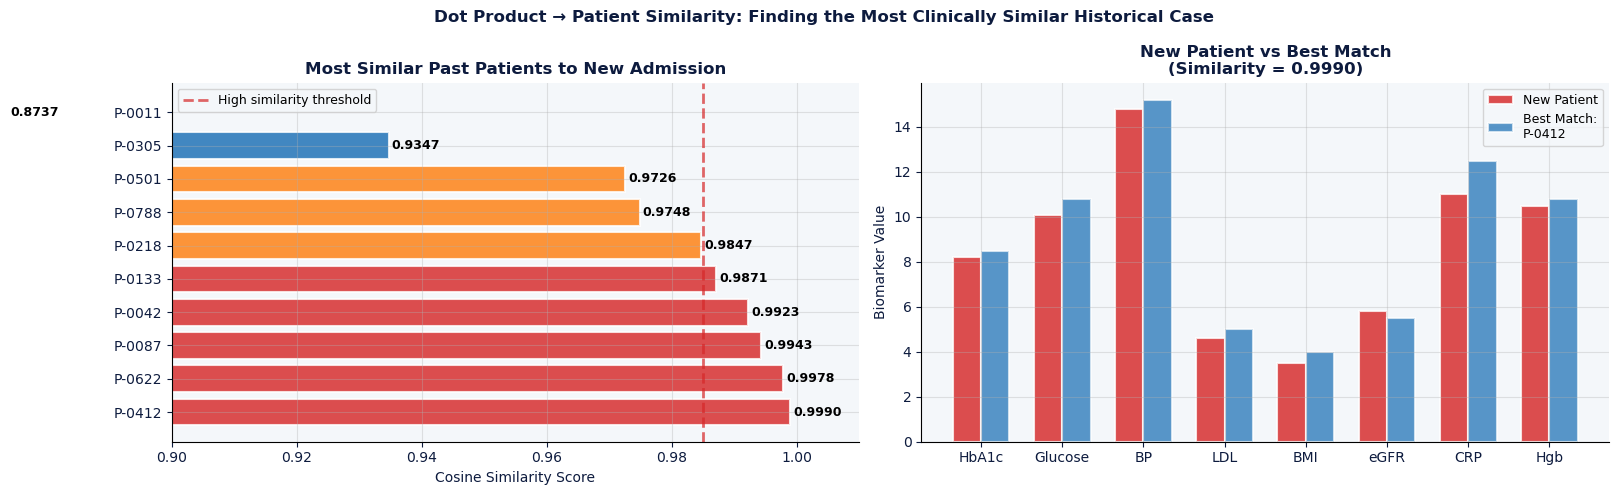

TOP 3 MOST SIMILAR PATIENTS:
  1. P-0412 (Metabolic syndrome)                → Similarity: 0.9990
  2. P-0622 (Pre-diabetic + obesity)            → Similarity: 0.9978
  3. P-0087 (T2D + HTN, poorly controlled)      → Similarity: 0.9943

🏥 Clinical Application: Case-Based Reasoning
   Systems like IBM Watson Health and Epic's AI use this principle:
   'Given this patient's biomarkers, what happened to the most similar
    patients we've seen before, and what treatment worked best?'


In [ ]:
# ═══════════════════════════════════════════════════════════════════
#  1.2  DOT PRODUCTS — Clinical Patient Similarity Matching
# ═══════════════════════════════════════════════════════════════════
print("━" * 62)
print("  1.2  DOT PRODUCTS — 'Find me the most similar past patient'")
print("━" * 62)

def cosine_similarity(a, b):
    """How clinically similar are two patients? (0=nothing in common, 1=identical)"""
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# New patient arriving in clinic
new_patient = np.array([8.2, 10.1, 14.8, 4.6, 3.5, 5.8, 11.0, 10.5])

# Historical patient database (10 past patients with known outcomes)
historical_db = {
    'P-0042 (Pre-diabetic, managed well)':   np.array([7.8,  9.2, 14.0, 4.1, 3.2, 6.5,  8.0, 11.5]),
    'P-0087 (T2D + HTN, poorly controlled)': np.array([8.9, 11.5, 15.5, 5.2, 3.8, 5.0, 14.2, 10.0]),
    'P-0011 (Healthy)':                      np.array([5.2,  5.1, 11.8, 2.8, 2.4, 9.2,  1.5, 14.2]),
    'P-0133 (T2D, early stage)':             np.array([7.5,  9.8, 13.5, 3.8, 3.0, 7.0,  7.5, 12.0]),
    'P-0218 (T2D + CKD)':                    np.array([9.1, 12.0, 16.0, 4.8, 4.1, 3.8, 16.0,  9.5]),
    'P-0305 (Hypertension only)':            np.array([5.8,  6.2, 17.0, 3.5, 3.3, 8.0,  4.0, 13.0]),
    'P-0412 (Metabolic syndrome)':           np.array([8.5, 10.8, 15.2, 5.0, 4.0, 5.5, 12.5, 10.8]),
    'P-0501 (T2D, well-controlled)':         np.array([7.1,  8.5, 13.0, 3.5, 3.1, 7.5,  6.0, 12.5]),
    'P-0622 (Pre-diabetic + obesity)':       np.array([8.0, 10.5, 14.2, 4.3, 4.5, 6.2, 10.0, 11.0]),
    'P-0788 (T2D + neuropathy)':             np.array([9.5, 13.2, 14.8, 5.5, 3.9, 5.2, 18.0,  9.0]),
}

similarities = {name: cosine_similarity(new_patient, vec)
                for name, vec in historical_db.items()}
sorted_sims = dict(sorted(similarities.items(), key=lambda x: x[1], reverse=True))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Dot Product → Patient Similarity: Finding the Most Clinically Similar Historical Case',
             fontsize=12, fontweight='bold', color=IMP_NAVY)

# Similarity bar chart
names  = [n.split('(')[0].strip() for n in sorted_sims.keys()]
scores = list(sorted_sims.values())
colours = [C_ALERT if s > 0.985 else C_WARN if s > 0.97 else C_LA
           for s in scores]
bars = axes[0].barh(names, scores, color=colours, alpha=0.82,
                    edgecolor='white', linewidth=1.5)
axes[0].set_xlim(0.90, 1.01)
axes[0].set_xlabel('Cosine Similarity Score')
axes[0].set_title('Most Similar Past Patients to New Admission',
                  fontweight='bold', color=IMP_NAVY)
axes[0].axvline(0.985, color=C_ALERT, linestyle='--', linewidth=2,
                alpha=0.7, label='High similarity threshold')
for bar, val in zip(bars, scores):
    axes[0].text(val + 0.0005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
axes[0].legend(fontsize=9)

# Radar-style comparison: new patient vs top match
top_match_name = list(sorted_sims.keys())[0]
top_match_vec  = historical_db[top_match_name]
short_labels   = ['HbA1c', 'Glucose', 'BP', 'LDL', 'BMI', 'eGFR', 'CRP', 'Hgb']
x_idx          = np.arange(len(short_labels))
w              = 0.35
axes[1].bar(x_idx - w/2, new_patient, w, label='New Patient',
            color=C_ALERT, alpha=0.82, edgecolor='white', linewidth=1.5)
axes[1].bar(x_idx + w/2, top_match_vec, w,
            label=f'Best Match:\n{top_match_name.split("(")[0].strip()}',
            color=C_LA, alpha=0.72, edgecolor='white', linewidth=1.5)
axes[1].set_xticks(x_idx)
axes[1].set_xticklabels(short_labels)
axes[1].set_ylabel('Biomarker Value')
axes[1].set_title(f'New Patient vs Best Match\n(Similarity = {scores[0]:.4f})',
                  fontweight='bold', color=IMP_NAVY)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("TOP 3 MOST SIMILAR PATIENTS:")
for i, (name, sim) in enumerate(list(sorted_sims.items())[:3]):
    print(f"  {i+1}. {name:<42} → Similarity: {sim:.4f}")
print()
print("🏥 Clinical Application: Case-Based Reasoning")
print("   Systems like IBM Watson Health and Epic's AI use this principle:")
print("   'Given this patient's biomarkers, what happened to the most similar")
print("    patients we've seen before, and what treatment worked best?'")


<div style="background:#EAF3FB;border-left:5px solid #1A6FB5;padding:20px;border-radius:8px;margin:16px 0;">
<h2 style="color:#1A6FB5;margin-top:0;">🔢 Mathematical Deep-Dive: Matrices & Matrix Multiplication</h2>

### What is a Matrix?

A matrix $\mathbf{A}$ is a **rectangular grid of numbers** with $m$ rows and $n$ columns, written $\mathbf{A} \in \mathbb{R}^{m \times n}$:

$$\mathbf{A} = \begin{pmatrix} a_{11} & a_{12} & a_{13} \\ a_{21} & a_{22} & a_{23} \\ a_{31} & a_{32} & a_{33} \end{pmatrix}$$

The element in row $i$, column $j$ is written $a_{ij}$ or $A[i,j]$.

**In healthcare:** a patient dataset of $m$ patients with $n$ features IS a matrix. One row = one patient. One column = one biomarker.

### Matrix–Vector Multiplication (how AI makes predictions)

If $\mathbf{A} \in \mathbb{R}^{m \times n}$ and $\mathbf{x} \in \mathbb{R}^n$, then $\mathbf{A}\mathbf{x} \in \mathbb{R}^m$:

$$(\mathbf{A}\mathbf{x})_i = \sum_{j=1}^{n} A_{ij}\, x_j \qquad \text{(each output row = dot product of that row with } \mathbf{x}\text{)}$$

**Worked Example (2×3 matrix × 3-vector):**

$$\begin{pmatrix}1 & 2 & 3\\4 & 5 & 6\end{pmatrix} \begin{pmatrix}7\\8\\9\end{pmatrix} = \begin{pmatrix}1{\cdot}7+2{\cdot}8+3{\cdot}9\\ 4{\cdot}7+5{\cdot}8+6{\cdot}9\end{pmatrix} = \begin{pmatrix}7+16+27\\ 28+40+54\end{pmatrix} = \begin{pmatrix}50\\122\end{pmatrix}$$

### Matrix–Matrix Multiplication

$\mathbf{C} = \mathbf{A}\mathbf{B}$ where $\mathbf{A} \in \mathbb{R}^{m \times k}$ and $\mathbf{B} \in \mathbb{R}^{k \times n}$:

$$C_{ij} = \sum_{l=1}^{k} A_{il}\, B_{lj}$$

The **inner dimensions must match**: $A$ has $k$ columns, $B$ has $k$ rows. Result is $(m \times n)$.

**Step-by-step 2×2 example:**

$$\begin{pmatrix}1&2\\3&4\end{pmatrix}\begin{pmatrix}5&6\\7&8\end{pmatrix}$$

$$C_{11}=1{\cdot}5+2{\cdot}7=19,\quad C_{12}=1{\cdot}6+2{\cdot}8=22$$
$$C_{21}=3{\cdot}5+4{\cdot}7=43,\quad C_{22}=3{\cdot}6+4{\cdot}8=50$$

$$\Rightarrow \mathbf{C} = \begin{pmatrix}19&22\\43&50\end{pmatrix}$$

### Matrix Transpose

$(\mathbf{A}^\top)_{ij} = A_{ji}$ — flip rows and columns:

$$\begin{pmatrix}1&2&3\\4&5&6\end{pmatrix}^\top = \begin{pmatrix}1&4\\2&5\\3&6\end{pmatrix}$$

### Image Convolution = Matrix Operation

An MRI scan is a matrix of pixel intensities. A filter (e.g. edge detector) is a small matrix called a **kernel** $\mathbf{K}$. Applying the filter = sliding $\mathbf{K}$ over the image and computing dot products at every position. This is **convolution** — the core operation of every convolutional neural network used in medical imaging.
</div>


In [ ]:
# ── WORKED MATHS: Matrix multiplication step by step ────────────────────────
import numpy as np

print("=" * 60)
print("  MATRIX MULTIPLICATION — Full Step-by-Step Working")
print("=" * 60)

# 2×3 patient feature matrix (2 patients, 3 features)
X = np.array([[7.8, 9.2, 14.0],
              [8.9, 11.5, 15.5]])

# 3×2 weight matrix (simulating a neural network layer)
W = np.array([[0.5, -0.2],
              [0.3,  0.8],
              [-0.1, 0.4]])

print(f"\nX  (2×3 patient matrix):\n{X}")
print(f"\nW  (3×2 weight matrix):\n{W}")
print(f"\nComputing Z = X @ W  →  shape ({X.shape[0]}×{X.shape[1]}) @ ({W.shape[0]}×{W.shape[1]}) = ({X.shape[0]}×{W.shape[1]})")

# Manual computation
Z = np.zeros((X.shape[0], W.shape[1]))
for i in range(X.shape[0]):
    for j in range(W.shape[1]):
        terms = [f"{X[i,k]:.1f}×{W[k,j]:.1f}" for k in range(X.shape[1])]
        val   = sum(X[i,k]*W[k,j] for k in range(X.shape[1]))
        Z[i,j] = val
        print(f"  Z[{i},{j}] = {' + '.join(terms)} = {val:.3f}")

print(f"\nResult Z = X @ W:\n{Z.round(3)}")
print(f"NumPy check:\n{(X @ W).round(3)}")

# Transpose
print(f"\nTranspose X^T  (3×2):\n{X.T}")
print("  Original X[0,1] = 9.2  →  X^T[1,0] = 9.2  ✓")
print("  Original X[1,2] = 15.5 →  X^T[2,1] = 15.5 ✓")

# Covariance matrix
X_c = X - X.mean(axis=0)
cov = (X_c.T @ X_c) / (X.shape[0] - 1)
print(f"\nCovariance matrix (X^T X / (n-1)):\n{cov.round(3)}")

  MATRIX MULTIPLICATION — Full Step-by-Step Working

X  (2×3 patient matrix):
[[ 7.8  9.2 14. ]
 [ 8.9 11.5 15.5]]

W  (3×2 weight matrix):
[[ 0.5 -0.2]
 [ 0.3  0.8]
 [-0.1  0.4]]

Computing Z = X @ W  →  shape (2×3) @ (3×2) = (2×2)
  Z[0,0] = 7.8×0.5 + 9.2×0.3 + 14.0×-0.1 = 5.260
  Z[0,1] = 7.8×-0.2 + 9.2×0.8 + 14.0×0.4 = 11.400
  Z[1,0] = 8.9×0.5 + 11.5×0.3 + 15.5×-0.1 = 6.350
  Z[1,1] = 8.9×-0.2 + 11.5×0.8 + 15.5×0.4 = 13.620

Result Z = X @ W:
[[ 5.26 11.4 ]
 [ 6.35 13.62]]
NumPy check:
[[ 5.26 11.4 ]
 [ 6.35 13.62]]

Transpose X^T  (3×2):
[[ 7.8  8.9]
 [ 9.2 11.5]
 [14.  15.5]]
  Original X[0,1] = 9.2  →  X^T[1,0] = 9.2  ✓
  Original X[1,2] = 15.5 →  X^T[2,1] = 15.5 ✓

Covariance matrix (X^T X / (n-1)):
[[0.605 1.265 0.825]
 [1.265 2.645 1.725]
 [0.825 1.725 1.125]]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  1.3  MATRICES — MRI and CT Scans Are Grids of Numbers
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


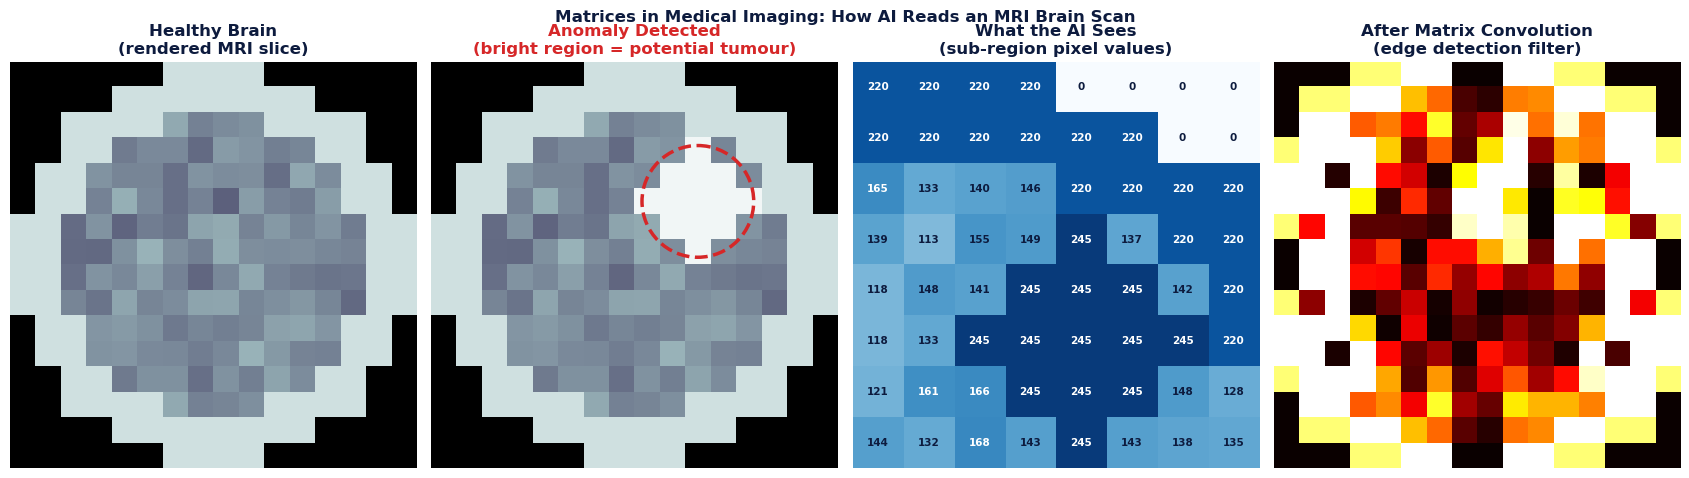

MRI scan matrix shape: (16, 16)  (16×16 simplified)
Real clinical MRI: typically 256×256×150 slices = 9,830,400 pixel values

🧠 Clinical Application: AI-Assisted Radiology
   - Google DeepMind's AI detects eye diseases from retinal scans (matrices)
   - Zebra Medical Vision reads CT scans using convolutional matrix operations
   - Every convolution filter applied to a scan is a matrix multiplication


In [ ]:
# ═══════════════════════════════════════════════════════════════════
#  1.3  MATRICES — MRI Scans as Pixel Matrices
# ═══════════════════════════════════════════════════════════════════
print("━" * 62)
print("  1.3  MATRICES — MRI and CT Scans Are Grids of Numbers")
print("━" * 62)

# Simulate a 16×16 greyscale MRI brain slice
# Values represent signal intensity (0=no signal, 255=maximum)
np.random.seed(7)
brain_base = np.zeros((16, 16))

# Skull ring
for i in range(16):
    for j in range(16):
        dist = np.sqrt((i - 7.5)**2 + (j - 7.5)**2)
        if 6.0 < dist < 7.8:
            brain_base[i, j] = 220
        elif dist <= 6.0:
            brain_base[i, j] = 140 + np.random.normal(0, 15)

# Simulate a tumour (bright region)
tumour_scan = brain_base.copy()
for i in range(16):
    for j in range(16):
        if np.sqrt((i - 5)**2 + (j - 10)**2) < 2.2:
            tumour_scan[i, j] = 245

# Edge-detection filter (simplified Sobel)
def sobel_edge(img):
    kernel_x = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
    from scipy.ndimage import convolve
    return np.clip(np.abs(convolve(img.astype(float), kernel_x)), 0, 255)

from scipy.ndimage import convolve
edges = sobel_edge(tumour_scan)

fig, axes = plt.subplots(1, 4, figsize=(17, 5))
fig.suptitle('Matrices in Medical Imaging: How AI Reads an MRI Brain Scan',
             fontsize=12, fontweight='bold', color=IMP_NAVY)

# Panel 1: Healthy scan
axes[0].imshow(brain_base, cmap='bone', vmin=0, vmax=255)
axes[0].set_title('Healthy Brain\n(rendered MRI slice)', fontweight='bold', color=IMP_NAVY)
axes[0].axis('off')

# Panel 2: Tumour scan
axes[1].imshow(tumour_scan, cmap='bone', vmin=0, vmax=255)
circle = plt.Circle((10, 5), 2.2, color=C_ALERT, fill=False, linewidth=2.5, linestyle='--')
axes[1].add_patch(circle)
axes[1].set_title('Anomaly Detected\n(bright region = potential tumour)', fontweight='bold', color=C_ALERT)
axes[1].axis('off')

# Panel 3: The numbers
axes[2].imshow(tumour_scan[0:8, 6:14], cmap='Blues', vmin=0, vmax=255)
for i in range(8):
    for j in range(8):
        val = int(tumour_scan[i, j+6])
        col = 'white' if val > 160 else IMP_NAVY
        axes[2].text(j, i, str(val), ha='center', va='center',
                     fontsize=7.5, fontweight='bold', color=col)
axes[2].set_title('What the AI Sees\n(sub-region pixel values)', fontweight='bold', color=IMP_NAVY)
axes[2].axis('off')

# Panel 4: Edge-detected
axes[3].imshow(edges, cmap='hot', vmin=0, vmax=255)
axes[3].set_title('After Matrix Convolution\n(edge detection filter)', fontweight='bold', color=IMP_NAVY)
axes[3].axis('off')

plt.tight_layout()
plt.show()

print(f"MRI scan matrix shape: {tumour_scan.shape}  (16×16 simplified)")
print(f"Real clinical MRI: typically 256×256×150 slices = {256*256*150:,} pixel values")
print()
print("🧠 Clinical Application: AI-Assisted Radiology")
print("   - Google DeepMind's AI detects eye diseases from retinal scans (matrices)")
print("   - Zebra Medical Vision reads CT scans using convolutional matrix operations")
print("   - Every convolution filter applied to a scan is a matrix multiplication")


<div style="background:#EAF3FB;border-left:5px solid #1A6FB5;padding:22px;border-radius:8px;margin:16px 0;">
<h2 style="color:#1A6FB5;margin-top:0;">📌 Concept: PCA — Turning a 50-Column Spreadsheet into a 2D Picture</h2>

### Plain English First
Imagine you have test results for 200 patients, each with 50 different blood markers. That is an overwhelming amount of information — like trying to understand a patient by reading 50 lab reports at once.

**PCA (Principal Component Analysis)** finds the most important patterns hidden inside all that data and summarises them into just 2 or 3 "summary scores" — making it easy to spot groups and differences at a glance.

---

### 🏥 The Analogy — A GP's Overall Health Assessment
Instead of reading through 50 individual test results, a GP looks for the **two or three biggest signals**: *"Is this patient metabolically unhealthy?"* and *"Is there significant inflammation?"*. PCA does exactly this — automatically — for any number of measurements.

---

### What PCA Does (Four Simple Steps)

| Step | What happens | Plain English |
|---|---|---|
| **1. Centre the data** | Subtract the average of each test | Put all patients on equal footing |
| **2. Find the main patterns** | Which combination of tests varies most across patients? | What separates patients most? |
| **3. Score each patient** | Give every patient a score on each pattern | One number summarising their position |
| **4. Visualise** | Plot patients in 2D using the top 2 patterns | See natural groups at a glance |

---

### 🩺 Healthcare Examples
- **Cancer genomics:** 20,000 gene expression levels → 2 summary scores. When plotted, cancer patients naturally cluster separately from healthy patients.
- **Diabetes care:** 15 metabolic markers → 1 summary score that predicts HbA1c trajectory.
- **ICU monitoring:** 12 vital signs → 2 scores that separate stable from deteriorating patients.

> **Key takeaway:** PCA turns a 50-column spreadsheet into a 2D picture where similar patients sit close together.
</div>


In [ ]:
# ════════════════════════════════════════════════════════════════════
# 1.5  PCA — Seeing Patient Groups in Complex Data
#      We reduce 10 blood markers to 2 summary scores and plot them
# ════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
IMP_NAVY = '#0D1B3E';  C_ALERT = '#D62728';  C_SAFE = '#2CA02C'
IMP_TEAL = '#009B8D'

# ── Simulate 150 patients with 10 blood markers ──────────────────
n = 75
markers = ['HbA1c','Glucose','BMI','CRP','LDL',
           'Systolic BP','Triglycerides','eGFR','WBC','Haemoglobin']

diabetic = np.random.randn(n, 10)
diabetic[:, 0:4] += 2.5          # elevated: HbA1c, Glucose, BMI, CRP

healthy  = np.random.randn(n, 10)
healthy[:, 9]   += 0.5           # higher haemoglobin in healthy group

X      = np.vstack([diabetic, healthy])
labels = ['Diabetic']*n + ['Healthy']*n

print("STEP 1 — Original data")
print(f"  {X.shape[0]} patients  ×  {X.shape[1]} blood markers  =  hard to visualise!")
print()

# ── Standardise so every marker is on the same scale ─────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("STEP 2 — Standardise each marker (same scale)")
print(f"  HbA1c mean: {X_scaled[:,0].mean():.2f}  SD: {X_scaled[:,0].std():.2f}")
print(f"  WBC   mean: {X_scaled[:,8].mean():.2f}  SD: {X_scaled[:,8].std():.2f}")
print("  (All markers now centred at 0 — none dominates just because of units)")
print()

# ── Find the main patterns (PCA) ──────────────────────────────────
cov = np.cov(X_scaled.T)
eigenvalues, eigenvectors = np.linalg.eigh(cov)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
var_explained = eigenvalues / eigenvalues.sum() * 100

print("STEP 3 — How much information does each summary score capture?")
for i in range(5):
    bar = '█' * int(var_explained[i] * 1.5)
    print(f"  Summary score {i+1}: {var_explained[i]:5.1f}%  {bar}")
print(f"  The top 2 scores together capture {var_explained[:2].sum():.1f}% of all variation")
print()

# ── Project each patient onto 2 summary scores ────────────────────
X_pca = X_scaled @ eigenvectors[:, :2]
print("STEP 4 — Each patient now described by just 2 numbers:")
print(f"  First diabetic patient: Score1 = {X_pca[0,0]:.2f},  Score2 = {X_pca[0,1]:.2f}")
print(f"  First healthy  patient: Score1 = {X_pca[n,0]:.2f},  Score2 = {X_pca[n,1]:.2f}")

# ── Visualise ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA: 10 Blood Markers Collapsed into 2 Summary Scores\n'
             'Similar patients cluster together automatically',
             fontsize=13, fontweight='bold', color=IMP_NAVY)

for grp, col, mk in [('Diabetic', C_ALERT, 'o'), ('Healthy', C_SAFE, 's')]:
    mask = [l == grp for l in labels]
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=col, marker=mk, alpha=0.60, s=60,
                    edgecolors='white', linewidth=0.5, label=grp)

axes[0].set_xlabel(f'Summary Score 1  ({var_explained[0]:.1f}% of variation)', fontsize=10)
axes[0].set_ylabel(f'Summary Score 2  ({var_explained[1]:.1f}% of variation)', fontsize=10)
axes[0].set_title('Each dot = one patient\nSimilar patients sit close together',
                   fontweight='bold', color=IMP_NAVY)
axes[0].legend(fontsize=11)

for grp, col in [('Diabetic', C_ALERT), ('Healthy', C_SAFE)]:
    mask = np.array([l == grp for l in labels])
    cx, cy = X_pca[mask,0].mean(), X_pca[mask,1].mean()
    axes[0].annotate(f'{grp}\ncluster', xy=(cx, cy), fontsize=9, color=col,
                     fontweight='bold', ha='center', va='center',
                     bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=col, alpha=0.85))

colours = [IMP_TEAL if i < 2 else '#C0C8D0' for i in range(6)]
axes[1].bar(range(1, 7), var_explained[:6], color=colours, edgecolor='white',
             linewidth=1.5, alpha=0.85)
axes[1].set_xlabel('Summary Score Number', fontsize=10)
axes[1].set_ylabel('Information Captured (%)', fontsize=10)
axes[1].set_title('Top 2 Scores Capture Most\nof the Useful Information',
                   fontweight='bold', color=IMP_NAVY)
axes[1].set_xticks(range(1, 7))
axes[1].axhline(sum(var_explained[:2]), color=IMP_TEAL, linestyle='--',
                 linewidth=2, label=f'Top 2 combined: {sum(var_explained[:2]):.1f}%')
axes[1].legend(fontsize=9)
for i, v in enumerate(var_explained[:6]):
    axes[1].text(i+1, v+0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print()
print("KEY TAKEAWAY:")
print("  Before PCA: each patient needs 10 numbers to describe them")
print("  After  PCA: each patient is described by 2 summary scores")
print("  Diabetic and healthy patients naturally separate into two groups")
print("  No one told the algorithm which patients were diabetic — it found the pattern itself")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  1.5  EIGENVECTORS & PCA — Compressing Genomic Data
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


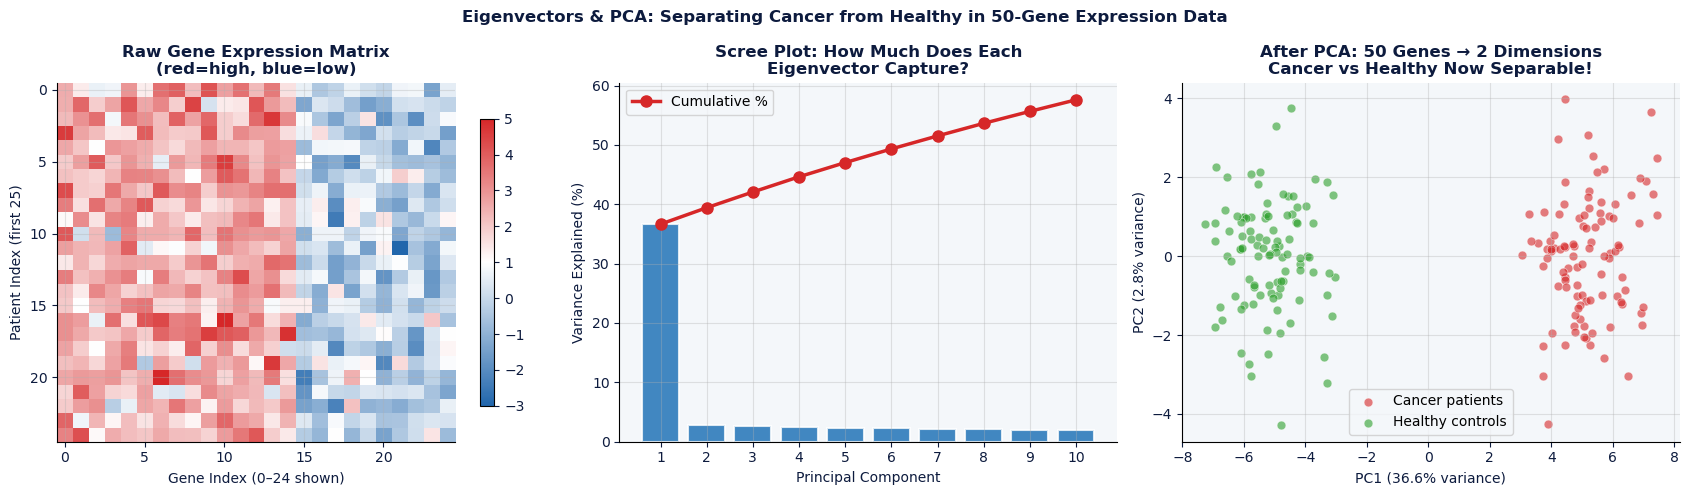

Original data shape : (200, 50)  (200 patients × 50 genes)
After PCA           : (200, 2)  (200 patients × 2 components)
Data compressed by  : 96%
PC1 alone explains  : 36.6% of all variation

🧬 Clinical Application: Cancer Genomics
   The Cancer Genome Atlas (TCGA) uses PCA on 20,000+ gene expression
   profiles to identify cancer subtypes and predict treatment response.
   Without eigenvectors, navigating 20,000 dimensions is impossible.


In [ ]:
# ═══════════════════════════════════════════════════════════════════
#  1.5  EIGENVECTORS — Genomic PCA: Finding Disease-Relevant Patterns
# ═══════════════════════════════════════════════════════════════════
print("━" * 62)
print("  1.5  EIGENVECTORS & PCA — Compressing Genomic Data")
print("━" * 62)

# Simulate gene expression data: 200 patients × 50 genes
# Two groups: cancer patients and healthy controls
n_cancer  = 100
n_healthy = 100
n_genes   = 50

# Cancer patients: elevated expression in oncogenes (genes 0-15)
cancer_data  = np.random.randn(n_cancer, n_genes)
cancer_data[:, :15] += 2.5  # oncogenes overexpressed
cancer_data[:, 35:] -= 1.0  # tumour suppressors underexpressed

healthy_data = np.random.randn(n_healthy, n_genes)

X_genes = np.vstack([cancer_data, healthy_data])
y_genes = np.array([1]*n_cancer + [0]*n_healthy)  # 1=cancer, 0=healthy

# PCA via eigenvectors
X_centred   = X_genes - X_genes.mean(axis=0)
cov_matrix  = np.cov(X_centred.T)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
idx         = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Project onto top 2 principal components
X_pca = X_centred @ eigenvectors[:, :2]
var_explained = eigenvalues / eigenvalues.sum() * 100

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Eigenvectors & PCA: Separating Cancer from Healthy in 50-Gene Expression Data',
             fontsize=12, fontweight='bold', color=IMP_NAVY)

# Raw gene expression heatmap (first 20 patients)
cmap_expr = LinearSegmentedColormap.from_list('expr', ['#2166AC','white','#D62728'])
im = axes[0].imshow(X_genes[:25, :25], cmap=cmap_expr, aspect='auto',
                    vmin=-3, vmax=5)
axes[0].set_xlabel('Gene Index (0–24 shown)')
axes[0].set_ylabel('Patient Index (first 25)')
axes[0].set_title('Raw Gene Expression Matrix\n(red=high, blue=low)',
                  fontweight='bold', color=IMP_NAVY)
plt.colorbar(im, ax=axes[0], shrink=0.8)

# Scree plot — variance explained per eigenvector
axes[1].bar(range(1, 11), var_explained[:10], color=C_LA, alpha=0.82,
            edgecolor='white', linewidth=1.5)
axes[1].plot(range(1, 11), np.cumsum(var_explained[:10]),
             'o-', color=C_ALERT, linewidth=2.5, markersize=8, label='Cumulative %')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Variance Explained (%)')
axes[1].set_title('Scree Plot: How Much Does Each\nEigenvector Capture?',
                  fontweight='bold', color=IMP_NAVY)
axes[1].legend()
axes[1].set_xticks(range(1, 11))

# PCA scatter — cancer vs healthy separated
for label, colour, name in [(1, C_ALERT, 'Cancer patients'),
                              (0, C_SAFE,  'Healthy controls')]:
    mask = y_genes == label
    axes[2].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=colour, alpha=0.6, s=40, label=name, edgecolors='white', linewidth=0.5)
axes[2].set_xlabel(f'PC1 ({var_explained[0]:.1f}% variance)')
axes[2].set_ylabel(f'PC2 ({var_explained[1]:.1f}% variance)')
axes[2].set_title('After PCA: 50 Genes → 2 Dimensions\nCancer vs Healthy Now Separable!',
                  fontweight='bold', color=IMP_NAVY)
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"Original data shape : {X_genes.shape}  (200 patients × 50 genes)")
print(f"After PCA           : {X_pca.shape}  (200 patients × 2 components)")
print(f"Data compressed by  : {(1 - 2/50)*100:.0f}%")
print(f"PC1 alone explains  : {var_explained[0]:.1f}% of all variation")
print()
print("🧬 Clinical Application: Cancer Genomics")
print("   The Cancer Genome Atlas (TCGA) uses PCA on 20,000+ gene expression")
print("   profiles to identify cancer subtypes and predict treatment response.")
print("   Without eigenvectors, navigating 20,000 dimensions is impossible.")


---
<div style="background:#C85E10;padding:22px 28px;border-radius:12px;color:white;">
  <h1 style="margin:0;font-size:1.8em;">📈 Part 2: How AI Learns — Gradient Descent in Plain English</h1>
  <p style="margin:8px 0 0 0;font-size:1.05em;opacity:0.9;">Learning from Mistakes · Adjusting Step by Step · Loss Functions</p>
</div>

### 💡 The Big Idea — in one sentence
> AI learns the same way you learn from a test: it makes a prediction, checks how wrong it was, adjusts, and repeats — millions of times — until it gets good.

### 🏥 Healthcare Applications
- A **retinal scan AI** predicts whether a patient has diabetic retinopathy. If wrong, it adjusts all its settings slightly and tries again on the next scan.
- A **sepsis early warning** system learns which patterns of vital signs reliably precede deterioration.
- A **drug dosage AI** learns how a patient's blood concentration changes over time and when to flag a dangerous level.

The mathematics behind this learning process is called **calculus** — specifically, the concept of a gradient (which direction leads to improvement). You do not need to be a mathematician to understand what it does.



<div style="background:#FDF0E8;border-left:5px solid #C85E10;padding:22px;border-radius:8px;margin:16px 0;">
<h2 style="color:#C85E10;margin-top:0;">📌 Concept: How AI Learns from Mistakes</h2>

### Plain English First
Every time an AI makes a prediction and gets it wrong, it needs to figure out two things:
1. **How wrong was it?** — measured by the *loss* (a score of how bad the prediction was)
2. **Which direction should it adjust?** — shown by the *gradient* (which way is "downhill" toward a better answer)

It then takes a small step in the right direction and tries again. Repeat millions of times → the AI improves.

---

### 🏥 The Analogy — Calibrating a Clinical Thermometer
Imagine you are calibrating a hospital thermometer. You test it against a reference standard of exactly 37.0°C. The thermometer reads 38.2°C — it is 1.2° too high.

- **The error (loss):** 1.2°C above the true value
- **The direction to adjust:** turn the dial down
- **The step size (learning rate):** turn it a little bit each time
- **Repeat:** test again, check the error, adjust, test again

AI does this exact cycle — but for millions of internal settings simultaneously, across thousands of training examples.

---

### The Three Key Ideas

| Term | What it means | In the thermometer analogy |
|---|---|---|
| **Loss** | How wrong the prediction is | The gap: 38.2 − 37.0 = 1.2°C error |
| **Gradient** | Which direction to adjust | "Reading is too high → turn the dial down" |
| **Learning rate** | How big each adjustment step is | Turn the dial a tiny bit vs a big turn |

---

### ⚠️ Why Step Size Matters

| Step size | What happens | Thermometer analogy |
|---|---|---|
| Too **small** | Takes forever to converge | Turning the dial by 0.001° at a time — all day |
| Too **large** | Overshoots, never settles | Turn too far → now it reads 35.5°C instead |
| Just **right** | Smooth journey to the correct answer | Small, confident adjustments → perfect calibration |

---

### 🩺 Real Example: Training a Diabetic Retinopathy Detector
1. Show the AI a retinal scan — it predicts "no disease" (wrong — patient has mild retinopathy)
2. Measure the loss: prediction confidence was very wrong
3. The gradient tells every internal setting: "adjust in this direction by this amount"
4. All millions of settings update by a tiny amount
5. Repeat with the next scan. And the next. Across 100,000 labelled images.
6. After training: the model correctly identifies retinopathy 87% of the time
</div>


In [ ]:
# ════════════════════════════════════════════════════════════════════
# 2.1  HOW AI LEARNS — Gradient Descent Step by Step
#      Scenario: calibrating a blood pressure prediction model
# ════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
IMP_NAVY = '#0D1B3E';  C_CA = '#C85E10';  C_SAFE = '#2CA02C'
C_ALERT  = '#D62728';  IMP_TEAL = '#009B8D'

# ── One adjustable setting — correct value is 3.5 ─────────────────
def error(w):       return (w - 3.5)**2 + 1.0   # bigger = more wrong
def direction(w):   return 2 * (w - 3.5)         # positive = too high, negative = too low

def run_learning(start, step_size, n_rounds):
    w = start
    record = [{'round': 0, 'setting': w, 'error': error(w)}]
    for t in range(1, n_rounds+1):
        grad = direction(w)
        w    = w - step_size * grad
        record.append({'round': t, 'setting': w, 'error': error(w)})
    return record

# ── Run with three different step sizes ──────────────────────────
hist_good = run_learning(0.5, step_size=0.35, n_rounds=15)
hist_slow = run_learning(0.5, step_size=0.05, n_rounds=15)
hist_big  = run_learning(0.5, step_size=0.98, n_rounds=15)

# ── Print step-by-step trace ──────────────────────────────────────
print("HOW THE AI LEARNS — Step-by-Step Trace")
print("Scenario: Calibrating a blood pressure prediction model")
print("Correct setting: 3.5  |  Starting guess: 0.5  |  Step size: 0.35")
print()
print(f"{'Round':>7}  {'Setting':>10}  {'Error':>10}  {'Too high or low?'}")
print("-" * 55)
for h in hist_good[:8]:
    w_val = h['setting']
    gap   = w_val - 3.5
    hint  = 'Too LOW  → adjust UP ↑' if gap < -0.05 else ('Too HIGH → adjust DOWN ↓' if gap > 0.05 else 'Just right ✓')
    print(f"{h['round']:>7}  {w_val:>10.4f}  {h['error']:>10.4f}  {hint}")
print(f"  ...  (continuing...)")
final = hist_good[-1]
print(f"{final['round']:>7}  {final['setting']:>10.4f}  {final['error']:>10.6f}  Converged ✓")

# ── Visualise ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('AI Learning by Adjusting Its Settings — Three Step Sizes Compared\n'
             'Goal: Find the correct setting of 3.5',
             fontsize=13, fontweight='bold', color=IMP_NAVY)

w_range    = np.linspace(-0.5, 7, 300)
error_curve = error(w_range)

configs = [
    (hist_good, C_SAFE,   '✅ Good step size (0.35)\nSmooth journey to the right answer'),
    (hist_slow, IMP_TEAL, '🐢 Too cautious (0.05)\nVery slow — still improving but takes long'),
    (hist_big,  C_ALERT,  '💥 Too aggressive (0.98)\nOvershoots — jumps past the answer'),
]

for ax, (hist, col, title) in zip(axes, configs):
    ax.plot(w_range, error_curve, color=IMP_NAVY, linewidth=2.5, alpha=0.6, label='Error curve')
    ws = [h['setting'] for h in hist]
    es = [h['error']   for h in hist]
    ax.plot(ws, es, 'o-', color=col, linewidth=2, markersize=7, alpha=0.9, label="AI's path")
    ax.plot(ws[0],  es[0],  's', color='black', markersize=12, zorder=6, label=f'Start (w={ws[0]})')
    ax.plot(ws[-1], es[-1], '*', color=col,     markersize=16, zorder=6, label=f'End  (w={ws[-1]:.2f})')
    ax.axvline(3.5, color='gold', linewidth=2.5, linestyle='--', label='Correct setting (3.5)')
    ax.set_xlabel('Model Setting', fontsize=10)
    ax.set_ylabel('Prediction Error', fontsize=10)
    ax.set_title(title, fontweight='bold', color=IMP_NAVY, fontsize=9)
    ax.legend(fontsize=7.5)
    ax.set_ylim(-0.5, 14);  ax.set_xlim(-0.5, 7.5)

plt.tight_layout()
plt.show()

print()
print("KEY INSIGHT:")
print("  Starting wrong (0.5), the AI measures its error, checks which way to adjust,")
print("  takes a step, and repeats. With the right step size it finds the answer every time.")
print()
print("  In a real retinopathy model, this happens across millions of settings")
print("  and thousands of training images — all simultaneously.")



<div style="background:#FDF0E8;border-left:5px solid #C85E10;padding:22px;border-radius:8px;margin:16px 0;">
<h2 style="color:#C85E10;margin-top:0;">📌 Concept: Loss Functions — How AI Scores Its Own Mistakes</h2>

### Plain English First
Before an AI can learn, it needs a **score** that tells it exactly how wrong it was. That score is called the **loss**. The lower the loss, the better the AI's prediction. The AI's entire training process is about making this score as small as possible.

---

### 🏥 The Analogy — A Medical Exam Marking Scheme
Think of a clinical exam marking scheme. Not all wrong answers are penalised equally:
- Getting a common, easy diagnosis slightly wrong → small penalty
- Missing a critical diagnosis like a pulmonary embolism when the signs are clear → heavy penalty

A loss function is the AI's marking scheme. **Different clinical tasks need different marking schemes.**

---

### Two Common Loss Functions in Healthcare AI

**Loss 1: Mean Squared Error — for predicting numbers**
> Used when: predicting glucose levels, blood pressure, length of stay

How it works: measure the gap between predicted and true value. Square it (so big errors are penalised more). Average across all patients.

Example: AI predicts blood glucose = 9.2 mmol/L, true value = 8.5 mmol/L
- Error = 0.7 → squared = 0.49 (small penalty)
- If AI was off by 2.0 → squared = 4.0 (much larger penalty — big errors hurt more)

---

**Loss 2: Cross-Entropy — for predicting Yes/No**
> Used when: diagnosing cancer (yes/no), predicting readmission (yes/no), sepsis alert (yes/no)

How it works: the AI gives a confidence score (0–1). The loss punishes you not just for being wrong, but for being **confidently wrong**.

| True diagnosis | AI confidence | Penalty |
|---|---|---|
| Cancer | 0.95 (confident it's cancer) | ✅ Small — right and confident |
| Cancer | 0.15 (thought it was healthy) | ❌ Huge — wrong and confident in wrong direction |
| Healthy | 0.90 (confident it's cancer) | ❌ Large — confidently wrong |

---

### 🩺 Clinical Weighting — Matching the Loss to the Stakes
In cancer screening, a missed cancer (false negative) is far worse than a false alarm (false positive). We can tell the AI this by **weighting the loss**:

> "Missing a cancer = 5× penalty of raising a false alarm"

This is not just a mathematical tweak — it is a **clinical decision** built directly into the AI's learning process.
</div>


In [ ]:
# ════════════════════════════════════════════════════════════════════
# 2.2  LOSS FUNCTIONS — How AI Scores Its Own Mistakes
#      Scenario: Cancer screening — which predictions are most wrong?
# ════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt

IMP_NAVY = '#0D1B3E';  C_CA = '#C85E10';  C_ALERT = '#D62728'
C_SAFE   = '#2CA02C';  IMP_TEAL = '#009B8D';  C_WARN = '#FF7F0E'

# ── 5 patient predictions ─────────────────────────────────────────
patients    = ['Patient 1', 'Patient 2', 'Patient 3', 'Patient 4', 'Patient 5']
true_diag   = [1,    0,    1,    1,    0   ]   # 1=cancer, 0=healthy
ai_confidence=[0.92, 0.08, 0.75, 0.15, 0.65]  # AI's cancer probability
eps = 1e-9

# ── Compute penalty for each patient ─────────────────────────────
print("HOW THE AI IS PENALISED — Cancer Screening Example")
print("=" * 70)
print(f"  AI confidence = how sure the AI is that this patient has cancer")
print()
print(f"{'Patient':<12} {'Actual':>9} {'AI says':>10} {'Penalty':>10}  Explanation")
print("-" * 70)

penalties = []
for pat, y, p in zip(patients, true_diag, ai_confidence):
    if y == 1:   # patient has cancer
        pen  = -np.log(p + eps)
        note = f'Cancer — AI {p:.0%} confident → {"✅ small penalty" if p>0.7 else "❌ BIG penalty (missed!)"}'
    else:        # patient is healthy
        pen  = -np.log(1 - p + eps)
        note = f'Healthy — AI {p:.0%} cancer score → {"❌ penalty (false alarm)" if p>0.3 else "✅ small penalty"}'
    penalties.append(pen)
    diagnosis = 'CANCER' if y==1 else 'HEALTHY'
    print(f"  {pat:<10} {diagnosis:>9} {p:>9.0%} {pen:>10.2f}  {note}")

avg = np.mean(penalties)
print("-" * 70)
print(f"  {'Average penalty':>33}  {avg:.2f}  ← AI tries to make this as low as possible")

# ── Visualise ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Loss Functions: How the AI Scores Its Own Mistakes — Cancer Screening',
             fontsize=13, fontweight='bold', color=IMP_NAVY)

# Panel 1: confidence vs penalty bar chart
x = np.arange(len(patients));  w = 0.35
tick_labels = [f'{p}\n({"Cancer" if y==1 else "Healthy"})' for p,y in zip(patients, true_diag)]
axes[0].bar(x - w/2, true_diag,     w, label='True (Cancer=1)', color=IMP_NAVY, alpha=0.72, edgecolor='white')
bar_cols = [C_ALERT if pen>1.0 else C_WARN if pen>0.3 else C_SAFE for pen in penalties]
axes[0].bar(x + w/2, ai_confidence, w, label='AI Confidence',   color=bar_cols, alpha=0.82, edgecolor='white')
axes[0].set_xticks(x);  axes[0].set_xticklabels(tick_labels, fontsize=8)
axes[0].set_ylabel('Score (0=healthy, 1=cancer)');  axes[0].set_ylim(0, 1.35)
axes[0].set_title('True Diagnosis vs AI Confidence', fontweight='bold', color=IMP_NAVY)
axes[0].legend(fontsize=9)

# Panel 2: penalty for each patient
bar_cols2 = [C_ALERT if p>1.0 else C_WARN if p>0.3 else C_SAFE for p in penalties]
bars = axes[1].bar(patients, penalties, color=bar_cols2, edgecolor='white', linewidth=1.8, alpha=0.85)
axes[1].axhline(avg, color=IMP_NAVY, linewidth=2.5, linestyle='--', label=f'Average penalty = {avg:.2f}')
axes[1].set_ylabel('Penalty (Loss)');  axes[1].set_xticklabels(patients, rotation=20, ha='right')
axes[1].set_title('Penalty per Patient\n(high = the AI made a bad mistake)', fontweight='bold', color=IMP_NAVY)
axes[1].legend(fontsize=9)
for bar, p in zip(bars, penalties):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.04,
                 f'{p:.2f}', ha='center', fontsize=11, fontweight='bold')

# Panel 3: the loss curve shape
p_vals = np.linspace(0.01, 0.99, 200)
axes[2].plot(p_vals, -np.log(p_vals),     color=C_SAFE,  linewidth=3,
             label='Patient HAS cancer\n(penalise low AI confidence)')
axes[2].plot(p_vals, -np.log(1-p_vals),   color=C_ALERT, linewidth=3, linestyle='--',
             label='Patient is HEALTHY\n(penalise high AI cancer score)')
axes[2].axvline(0.5, color=IMP_NAVY, linewidth=2, linestyle=':', alpha=0.6, label='50% decision threshold')
axes[2].set_xlabel("AI's Cancer Confidence Score (0–1)");  axes[2].set_ylabel('Penalty')
axes[2].set_ylim(0, 5);  axes[2].set_xlim(0, 1)
axes[2].set_title('Loss Curve: Confident and Wrong = Huge Penalty',
                   fontweight='bold', color=IMP_NAVY)
axes[2].legend(fontsize=8.5)
axes[2].annotate('Confident\nand WRONG\n→ huge penalty', xy=(0.05, 4.0),
                  xytext=(0.25, 4.2), fontsize=8, color=C_SAFE, fontweight='bold',
                  arrowprops=dict(arrowstyle='->', color=C_SAFE))

plt.tight_layout()
plt.show()

print()
print("KEY INSIGHTS:")
print("  Patient 4 has cancer but AI only gave 15% confidence → large penalty (1.9)")
print("  Patient 1 has cancer and AI gave 92% confidence → tiny penalty (0.08)")
print()
print("  The AI's entire training is about reducing this average penalty.")
print("  In clinical AI, we can weight the penalty for missed cancers higher →")
print("  this trains the model to be more cautious and catch more real cases.")


---
<div style="background:#7A38B8;padding:22px 28px;border-radius:12px;color:white;">
  <h1 style="margin:0;font-size:1.8em;">🎲 Part 3: Probability &amp; Statistics</h1>
  <p style="margin:8px 0 0 0;font-size:1.05em;opacity:0.9;">Bayes Theorem · Distributions · Mean &amp; Variance · MLE · Conditional Probability</p>
</div>

### 💡 The Big Idea
> **Medicine has always been probabilistic.** 'There is an 80% chance this is benign.' 'Patients with this profile have a 1-in-4 chance of readmission.' Probability gives us the mathematical language to express, calculate, and act on clinical uncertainty.

### 🏥 Healthcare Applications
- **Clinical trial design** — how many patients do we need to detect a real drug effect?
- **ICU readmission prediction** — what is the probability this patient returns within 30 days?
- **Diagnostic test interpretation** — what does a positive test *actually* mean for *this* patient?
- **Sepsis early warning systems** — tracking the probability of deterioration in real time


<div style="background:#F3EBF8;border-left:5px solid #7A38B8;padding:22px;border-radius:8px;margin:16px 0;">
<h2 style="color:#7A38B8;margin-top:0;">📌 Concept: Bayes' Theorem — Updating What We Believe</h2>

### Plain English First
Bayes' Theorem answers one simple question:

> **"Given this new test result, how should I update my assessment of this patient?"**

In medicine, we constantly update our thinking as new information arrives. Bayes is the mathematics of that process — and it produces results that often surprise even experienced clinicians.

---

### 🏥 The Analogy — A GP Updating Their Assessment
A GP sees a 55-year-old patient presenting with fatigue:

1. **Before any tests:** "Fatigue at this age — about 5% chance of anaemia in this population." *(This is the prior — background rate)*
2. **Blood test shows low haemoglobin:** "This result is much more common in anaemia than in healthy patients." *(New evidence from the test)*
3. **Updated belief:** "Now I estimate roughly 80% probability of anaemia." *(This is the posterior — updated belief)*

Bayes' Theorem is the formula that does step 3 automatically and correctly.

---

### The Three Numbers You Need

| What | Clinical name | Mammography example |
|---|---|---|
| How common is the disease? | **Prevalence (prior)** | 1.2% of women aged 50–60 have breast cancer |
| How often does AI catch real cases? | **Sensitivity** | AI flags 87% of true cancers |
| How often does AI flag healthy people? | **False positive rate** | AI flags 9% of healthy women |

---

### ⚠️ The Surprising Result — Low Disease = Many False Alarms
Even a good AI produces many false alarms when the disease is rare. Here is why:

Out of 10,000 women screened:
- **120** actually have cancer → AI catches **104** of them ✅
- **9,880** are healthy → AI falsely flags **889** of them ⚠️

When the AI flags someone: **104 real + 889 false = 993 total flagged**

Probability of truly having cancer after a positive flag = **104 ÷ 993 = 10.5%**

> This is not a failure. It is mathematics. And it is why AI assists clinicians rather than replacing their judgement.
</div>


In [ ]:
# ════════════════════════════════════════════════════════════════════
# 3.1  BAYES' THEOREM — What Does a Positive AI Result Really Mean?
#      Scenario: AI-assisted mammography screening
# ════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt

IMP_NAVY = '#0D1B3E';  C_PR = '#7A38B8';  C_ALERT = '#D62728'
C_SAFE   = '#2CA02C';  C_WARN = '#FF7F0E'; IMP_TEAL = '#009B8D'

prevalence  = 0.012   # 1.2% of women aged 50–60 have breast cancer
sensitivity = 0.87    # AI catches 87% of real cancers
fpr         = 0.09    # AI incorrectly flags 9% of healthy women

# ── Natural frequencies — easiest way to understand Bayes ─────────
N         = 10_000
n_cancer  = int(N * prevalence)
n_healthy = N - n_cancer
TP = int(n_cancer  * sensitivity)   # correctly caught
FN = n_cancer - TP                  # missed cancers
FP = int(n_healthy * fpr)           # healthy people wrongly flagged
TN = n_healthy - FP

total_flagged = TP + FP
ppv = TP / total_flagged            # true probability of cancer given positive flag

print("MAMMOGRAPHY AI — What Does a Positive Flag Mean?")
print("=" * 58)
print(f"  Start with 10,000 women (aged 50–60)")
print(f"  Background rate: {prevalence*100:.1f}% have breast cancer")
print()
print(f"  Of the {n_cancer:,} who HAVE breast cancer:")
print(f"    AI correctly flags: {TP:,}  ✅")
print(f"    AI misses:          {FN:,}  ❌  (false negatives)")
print()
print(f"  Of the {n_healthy:,} who do NOT have breast cancer:")
print(f"    AI correctly clears:{TN:,}  ✅")
print(f"    AI wrongly flags:   {FP:,}  ⚠️  (false positives)")
print()
print(f"  TOTAL flagged as HIGH RISK: {TP} + {FP} = {total_flagged}")
print(f"  Of those flagged, {TP} actually have cancer")
print(f"  So: probability of cancer given a HIGH RISK flag = {TP}/{total_flagged} = {ppv*100:.1f}%")
print()
print(f"  ⭐ Only {ppv*100:.1f}% of HIGH RISK flags are true cancers")
print(f"     That is why every positive result needs clinical follow-up")

# ── Show how prevalence changes the picture ───────────────────────
prev_range = np.linspace(0.001, 0.30, 300)
ppv_curve  = [(sensitivity*p) / (sensitivity*p + fpr*(1-p)) for p in prev_range]

# ── Visualise ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Bayes' Theorem: What a Positive AI Mammography Flag Really Means",
             fontsize=12, fontweight='bold', color=IMP_NAVY)

# Panel 1: Natural frequency tree
cats   = ['All women\nscreened', 'Truly have\ncancer', 'AI flags\nHIGH RISK',
           '✅ True\npositives', '⚠️ False\nalarms']
vals   = [N, n_cancer, total_flagged, TP, FP]
bcols  = [IMP_NAVY, C_ALERT, C_WARN, C_SAFE, C_PR]
bars   = axes[0].bar(cats, vals, color=bcols, alpha=0.82, edgecolor='white', linewidth=2)
axes[0].set_ylabel('Number of Women');  axes[0].tick_params(axis='x', labelsize=8)
axes[0].set_title(f'Out of {N:,} Women Screened', fontweight='bold', color=IMP_NAVY)
for bar, v in zip(bars, vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+40,
                 f'{v:,}', ha='center', fontweight='bold', fontsize=10)

# Panel 2: Before vs after
axes[1].barh(['BEFORE test\n(1.2% background\ncancer rate)',
               'AFTER positive\nAI flag\n(10.5% now)'],
              [prevalence*100, ppv*100],
              color=[IMP_TEAL, C_ALERT], alpha=0.82, height=0.42,
              edgecolor='white', linewidth=2)
axes[1].set_xlabel('Probability of Having Cancer (%)')
axes[1].set_title("How the Test Updates Our Belief\nFrom 1.2% to 10.5%",
                   fontweight='bold', color=IMP_NAVY)
axes[1].axvline(50, color=IMP_NAVY, linestyle='--', alpha=0.4, label='50% threshold')
axes[1].legend(fontsize=9)
for i, v in enumerate([prevalence*100, ppv*100]):
    axes[1].text(v+0.5, i, f'{v:.1f}%', va='center', fontweight='bold', fontsize=13)

# Panel 3: How prevalence changes the picture
axes[2].plot(np.array(prev_range)*100, np.array(ppv_curve)*100,
             color=C_PR, linewidth=3)
axes[2].fill_between(np.array(prev_range)*100, np.array(ppv_curve)*100,
                      alpha=0.15, color=C_PR)
axes[2].scatter([prevalence*100], [ppv*100], color=C_ALERT, s=200, zorder=5,
                 label=f'Our case: {prevalence*100:.1f}% → {ppv*100:.1f}% after positive')
axes[2].axhline(50, color=IMP_NAVY, linestyle='--', alpha=0.5, label='50% threshold')
axes[2].set_xlabel('Disease Prevalence in the Population (%)')
axes[2].set_ylabel('True Probability of Disease After Positive Flag (%)')
axes[2].set_title('The Rarer the Disease,\nthe More False Alarms We Get',
                   fontweight='bold', color=IMP_NAVY)
axes[2].legend(fontsize=8.5);  axes[2].set_ylim(0, 105)

plt.tight_layout()
plt.show()

print()
print("KEY TAKEAWAY:")
print("  A 1.2% background rate means most positive AI flags are false alarms.")
print("  This is NOT because the AI is poor — it is basic mathematics.")
print("  Solution: AI flags the cases, clinicians do the follow-up.")
print("  Together they are faster and more accurate than either alone.")



<div style="background:#F3EBF8;border-left:5px solid #7A38B8;padding:22px;border-radius:8px;margin:16px 0;">
<h2 style="color:#7A38B8;margin-top:0;">📌 Concept: Distributions — What Does "Normal" Look Like?</h2>

### Plain English First
A **distribution** shows how a measurement is spread across a population.

If you measured the HbA1c of 10,000 people: most would be between 4.5–6.0%, fewer would be very low or very high, and the majority would cluster around 5.2%. That pattern — high in the middle, tapering at the edges — is a **distribution**.

---

### 🏥 The Analogy — A Height Chart on a GP's Wall
Plot the height of every adult patient who came to your clinic this year:
- Most cluster around 170cm
- Very few are under 150cm or over 195cm
- The shape is a **bell curve** — the most common distribution in medicine

The same bell shape appears for blood pressure, HbA1c, cholesterol, and hundreds of other biomarkers in a healthy population.

---

### Three Shapes You Will See in Healthcare

| Shape | Name | Healthcare Example |
|---|---|---|
| **Bell curve** | Normal distribution | HbA1c in a population; blood pressure; adult height |
| **Long tail to the right** | Log-normal (right-skewed) | Hospital length of stay — most patients leave in days, a few stay weeks |
| **Two humps** | Bimodal | Heart rate in ICU — one group is stable (~78 bpm), another is deteriorating (~112 bpm) |

---

### Mean and Standard Deviation — The Two Numbers That Describe a Distribution

- **Mean:** where the centre sits (the typical value)
- **Standard deviation (SD):** how spread out values are

**Clinical rule of thumb:** the "normal range" for most lab tests is the mean ± 2 standard deviations. This covers 95% of healthy individuals.

A result more than 2 SD from the mean is flagged as outside the normal range — and this is exactly what AI anomaly detection does.

---

### 🩺 Why This Matters for AI
AI learns what "normal" looks like by studying thousands of patients. When a new patient's results fall far outside the expected distribution, the AI raises an alert. This is the foundation of **early warning systems** like NEWS2 and sepsis detectors.
</div>


In [ ]:
# ════════════════════════════════════════════════════════════════════
# 3.2  DISTRIBUTIONS — Understanding "Normal" in Clinical Data
# ════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

np.random.seed(21)
IMP_NAVY = '#0D1B3E';  C_PR = '#7A38B8';  C_ALERT = '#D62728'
C_SAFE   = '#2CA02C';  C_WARN = '#FF7F0E'; IMP_TEAL = '#009B8D'

# ── Three datasets ────────────────────────────────────────────────
healthy_hba1c   = np.random.normal(5.2, 0.35, 2000)
prediab_hba1c   = np.random.normal(6.0, 0.40, 800)
diabetic_hba1c  = np.random.normal(8.2, 1.20, 1200)
los             = np.random.lognormal(mean=1.5, sigma=0.6, size=2000)
stable_hr       = np.random.normal(78,  10, 2000)
deteriorating_hr= np.random.normal(112, 18, 500)
all_hr          = np.concatenate([stable_hr, deteriorating_hr])

# ── Print statistics ──────────────────────────────────────────────
print("UNDERSTANDING CLINICAL DISTRIBUTIONS")
print("=" * 58)
print()
print("HbA1c — Three Patient Groups")
print(f"  {'Group':<16} {'Mean':>6}  {'SD':>6}  {'95% range'}")
print("  " + "-" * 46)
for name, data in [('Healthy', healthy_hba1c), ('Pre-diabetic', prediab_hba1c), ('Diabetic', diabetic_hba1c)]:
    lo = data.mean() - 2*data.std()
    hi = data.mean() + 2*data.std()
    print(f"  {name:<16} {data.mean():>6.2f}  {data.std():>6.2f}  [{lo:.2f} – {hi:.2f}]")

print()
print("Hospital Length of Stay (right-skewed):")
print(f"  Mean   = {los.mean():.1f} days  ← pulled up by long-stay patients")
print(f"  Median = {np.median(los):.1f} days  ← better summary of the typical patient")
print(f"  80% of patients leave within {np.percentile(los, 80):.0f} days")

print()
print("ICU Heart Rate (bimodal — two hidden groups):")
print(f"  Stable group:       {stable_hr.mean():.0f} bpm")
print(f"  Deteriorating group:{deteriorating_hr.mean():.0f} bpm")
print(f"  AI uses this split to decide when to escalate care")

# ── Visualise ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Three Distribution Shapes in Healthcare Data',
             fontsize=13, fontweight='bold', color=IMP_NAVY)

# Panel 1: HbA1c bell curves
x = np.linspace(3, 13, 300)
for data, col, lbl, mu, sig in [
    (healthy_hba1c,  C_SAFE,  'Healthy (5.2%)',     5.2, 0.35),
    (prediab_hba1c,  C_WARN,  'Pre-diabetic (6.0%)',6.0, 0.40),
    (diabetic_hba1c, C_ALERT, 'Diabetic (8.2%)',    8.2, 1.20),
]:
    axes[0].hist(data, bins=50, density=True, alpha=0.35, color=col, edgecolor='white')
    axes[0].plot(x, stats.norm.pdf(x, mu, sig), color=col, linewidth=3, label=lbl)

normal_lo = 5.2 - 2*0.35;  normal_hi = 5.2 + 2*0.35
axes[0].axvspan(normal_lo, normal_hi, alpha=0.10, color=C_SAFE, label=f'Normal range (±2 SD)')
axes[0].axvline(6.5, color=IMP_NAVY, linewidth=2.5, linestyle='--', label='Diabetes threshold (6.5%)')
axes[0].set_xlabel('HbA1c (%)');  axes[0].set_ylabel('Fraction of Patients')
axes[0].set_title('Bell Curve — HbA1c\nThree Patient Groups', fontweight='bold', color=IMP_NAVY)
axes[0].legend(fontsize=8)

# Panel 2: LOS right-skewed
axes[1].hist(los, bins=50, density=True, color=C_PR, alpha=0.60, edgecolor='white', label='Patient LOS')
x_los = np.linspace(0.1, 30, 200)
axes[1].plot(x_los, stats.lognorm.pdf(x_los, 0.6, scale=np.exp(1.5)),
              color=IMP_NAVY, linewidth=3, label='Fitted curve')
axes[1].axvline(np.median(los), color=C_SAFE,  linewidth=2.5, linestyle='--',
                 label=f'Median = {np.median(los):.1f} days')
axes[1].axvline(los.mean(),     color=C_ALERT, linewidth=2.5, linestyle=':',
                 label=f'Mean   = {los.mean():.1f} days')
axes[1].set_xlabel('Length of Stay (days)');  axes[1].set_xlim(0, 25)
axes[1].set_ylabel('Fraction of Patients')
axes[1].set_title('Right-Skewed — Hospital Length of Stay\nMean > Median due to long-stay outliers',
                   fontweight='bold', color=IMP_NAVY)
axes[1].legend(fontsize=8.5)

# Panel 3: ICU HR bimodal
axes[2].hist(all_hr, bins=60, density=True, color=C_PR, alpha=0.50, edgecolor='white', label='All ICU patients')
x_hr = np.linspace(30, 170, 300)
axes[2].plot(x_hr, 0.8*stats.norm.pdf(x_hr, 78,  10), color=C_SAFE,  linewidth=3, label='Stable (78 bpm)')
axes[2].plot(x_hr, 0.2*stats.norm.pdf(x_hr, 112, 18), color=C_ALERT, linewidth=3, label='Deteriorating (112 bpm)')
axes[2].axvline(100, color=IMP_NAVY, linewidth=2.5, linestyle='--', label='Alert at 100 bpm')
axes[2].set_xlabel('Heart Rate (bpm)');  axes[2].set_ylabel('Fraction of Patients')
axes[2].set_title('Bimodal — ICU Heart Rate\nTwo Hidden Patient Groups',
                   fontweight='bold', color=IMP_NAVY)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print()
print("KEY TAKEAWAY:")
print("  Bell curve:   Most patients cluster in the middle — define 'normal range'")
print("  Right-skewed: A few extreme cases pull the average — use median, not mean")
print("  Bimodal:      Two distinct patient groups hiding in one dataset")
print()
print("  AI learns which distribution each measurement should follow.")
print("  When a patient's reading falls far outside that distribution → alert raised.")



<div style="background:#F3EBF8;border-left:5px solid #7A38B8;padding:22px;border-radius:8px;margin:16px 0;">
<h2 style="color:#7A38B8;margin-top:0;">📌 Concept: Does the Drug Work? Reading a Clinical Trial</h2>

### Plain English First
MLE (Maximum Likelihood Estimation) sounds technical, but in practice it answers a simple question:

> **"Given the results we collected, what is the most likely true effect of this treatment?"**

In a clinical trial, MLE gives us the **best estimate** of the average outcome and how confident we can be in it.

---

### 🏥 The Analogy — Weighing a Patient on a Broken Scale
Your clinic's scale sometimes reads a little high, sometimes a little low. You weigh the same patient 10 times and get slightly different readings. The **best estimate** of the true weight is the average of those 10 readings — that is exactly what MLE does.

---

### The Three Results Every Clinical Trial Reports

**1. The effect size:** How much did the treatment group improve compared to placebo?
> "HbA1c dropped by 1.2% in the drug group vs 0.3% in placebo — a 0.9% advantage"

**2. The confidence interval:** How precise is that estimate?
> "95% confidence interval: [0.6%, 1.2%]" — we are 95% confident the true effect is in this range
> If the interval does not include zero → the drug works

**3. The p-value:** Could this result just be random chance?
> p < 0.05 → very unlikely to be chance → drug probably works  
> p > 0.05 → could easily be chance → we cannot conclude the drug works

---

### 🩺 How to Read a p-value Without the Maths

Think of the p-value as answering: *"If we ran this trial 100 times on a drug that actually did nothing, how often would we see a result this big just by luck?"*

| p-value | Translation |
|---|---|
| p = 0.001 | Only 1 in 1,000 chance this is a fluke |
| p = 0.04  | 4 in 100 chance — still unlikely to be luck |
| p = 0.20  | 1 in 5 chance — could easily be random |

---

### 🩺 Real Example: COVID-19 Vaccine Trials
Pfizer's trial enrolled 44,000 people. The observed efficacy was 95%. The p-value was vanishingly small. The result was almost certainly not due to random chance — the confidence interval did not come close to zero.
</div>


In [ ]:
# ════════════════════════════════════════════════════════════════════
# 3.3  DOES THE DRUG WORK? — Reading a Clinical Trial Simply
#      Scenario: New diabetes drug vs placebo (HbA1c reduction)
# ════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

np.random.seed(55)
IMP_NAVY = '#0D1B3E';  C_PR = '#7A38B8';  C_SAFE = '#2CA02C'
C_ALERT  = '#D62728';  IMP_TEAL = '#009B8D';  C_WARN = '#FF7F0E'

n               = 150
drug_reduction  = np.random.normal(1.2, 0.8, n)   # drug group
placebo_reduction=np.random.normal(0.3, 0.7, n)   # placebo group

drug_mean       = drug_reduction.mean()
placebo_mean    = placebo_reduction.mean()
effect          = drug_mean - placebo_mean
se              = np.sqrt(drug_reduction.var(ddof=1)/n + placebo_reduction.var(ddof=1)/n)
ci_lo, ci_hi    = effect - 1.96*se, effect + 1.96*se
z_stat          = effect / se
p_value         = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print("CLINICAL TRIAL RESULTS — New Diabetes Drug")
print("=" * 58)
print(f"  {n} patients in each group, measured over 6 months")
print()
print(f"  Drug group HbA1c improvement:    {drug_mean:.2f}%  (avg)")
print(f"  Placebo group HbA1c improvement: {placebo_mean:.2f}%  (avg)")
print(f"  ──────────────────────────────────────────────────")
print(f"  Drug advantage over placebo:      {effect:.2f}%")
print(f"  95% Confidence Interval:         [{ci_lo:.2f}%, {ci_hi:.2f}%]")
print()
print(f"  Does the confidence interval include zero?  {'YES — drug may not work' if ci_lo < 0 else 'NO — drug works!'}")
print()
print(f"  p-value = {p_value:.4f}")
if p_value < 0.001:
    reading = "Very strong evidence drug works (p < 0.001)"
elif p_value < 0.05:
    reading = "Significant evidence drug works (p < 0.05)"
else:
    reading = "Not enough evidence to conclude drug works"
print(f"  Reading:  {reading}")
print()
print(f"  In plain English: if this drug did NOTHING,")
print(f"  we would see a result this large by random chance")
print(f"  only {p_value*100:.2f}% of the time.")

# ── Visualise ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Does the Drug Work? — Reading the Clinical Trial Results\n"
             "Outcome: HbA1c Reduction (%) After 6 Months",
             fontsize=12, fontweight='bold', color=IMP_NAVY)

# Panel 1: Outcome distributions
x_r = np.linspace(-2.5, 4.5, 300)
for data, col, lbl, mu, sd in [
    (drug_reduction,    C_SAFE, f'Drug group (avg {drug_mean:.2f}%)',    drug_mean,    drug_reduction.std()),
    (placebo_reduction, C_PR,   f'Placebo (avg {placebo_mean:.2f}%)', placebo_mean, placebo_reduction.std()),
]:
    axes[0].hist(data, bins=25, density=True, alpha=0.45, color=col, edgecolor='white')
    axes[0].plot(x_r, stats.norm.pdf(x_r, mu, sd), color=col, linewidth=3, label=lbl)
axes[0].axvline(drug_mean,    color=C_SAFE, linewidth=2.5, linestyle='--')
axes[0].axvline(placebo_mean, color=C_PR,   linewidth=2.5, linestyle=':')
axes[0].set_xlabel('HbA1c Reduction (%)');  axes[0].set_ylabel('Fraction of Patients')
axes[0].set_title('Spread of Outcomes\nin Each Group', fontweight='bold', color=IMP_NAVY)
axes[0].legend(fontsize=8.5)

# Panel 2: Effect size with confidence interval
axes[1].barh(['Placebo\n(control)', 'New Drug\n(treatment)'],
              [placebo_mean, drug_mean],
              xerr=[placebo_reduction.std()/np.sqrt(n)*1.96,
                    drug_reduction.std()/np.sqrt(n)*1.96],
              color=[C_PR, C_SAFE], alpha=0.82, height=0.40,
              capsize=12, edgecolor='white', linewidth=2,
              error_kw={'linewidth': 3, 'ecolor': IMP_NAVY})
axes[1].axvline(0, color=IMP_NAVY, linewidth=1.5, linestyle='--', alpha=0.5)
axes[1].set_xlabel('Mean HbA1c Reduction (%)  ±  95% Confidence Interval')
axes[1].set_title('Average Outcome Per Group\n(error bars = uncertainty in the estimate)',
                   fontweight='bold', color=IMP_NAVY)
for val, ypos, col in [(drug_mean, 1, C_SAFE), (placebo_mean, 0, C_PR)]:
    axes[1].text(val+0.04, ypos, f'{val:.2f}%', va='center', fontsize=12, fontweight='bold', color=col)

# Panel 3: p-value visualisation
x_z = np.linspace(-5, 5, 500)
axes[2].plot(x_z, stats.norm.pdf(x_z), color=IMP_NAVY, linewidth=2.5,
              label="Expected if drug does nothing")
axes[2].fill_between(x_z, stats.norm.pdf(x_z), where=(np.abs(x_z) >= 1.96),
                      alpha=0.30, color=C_ALERT, label='Unusual zone (5% of results)')
axes[2].axvline( z_stat, color=C_SAFE, linewidth=3.5, linestyle='--', label=f'Our result (far out here!)')
axes[2].axvline(-z_stat, color=C_SAFE, linewidth=3.5, linestyle='--')
axes[2].set_xlabel('How many standard steps from zero?');  axes[2].set_ylabel('Probability')
axes[2].set_title(f'Is Our Result Just Random Luck?\np-value = {p_value:.4f}  →  Almost certainly not',
                   fontweight='bold', color=IMP_NAVY)
axes[2].legend(fontsize=8)
if z_stat > 2:
    axes[2].annotate('Our result is WAY\nout in the unusual zone →\nVery unlikely to be chance',
                      xy=(min(z_stat, 4.5), 0.05), xytext=(1.5, 0.25), fontsize=8,
                      color=C_SAFE, fontweight='bold',
                      arrowprops=dict(arrowstyle='->', color=C_SAFE))

plt.tight_layout()
plt.show()

print()
print("KEY TAKEAWAY:")
print(f"  Drug reduced HbA1c by {drug_mean:.1f}%  vs  placebo {placebo_mean:.1f}%")
print(f"  The {effect:.1f}% difference is {z_stat:.0f} standard steps from zero")
print(f"  p-value = {p_value:.4f} — extremely unlikely to be random chance")
print(f"  The confidence interval [{ci_lo:.2f}, {ci_hi:.2f}] does not cross zero → drug works")


---
<div style="background:#0A8A5A;padding:22px 28px;border-radius:12px;color:white;">
  <h1 style="margin:0;font-size:1.8em;">⚙️ Part 4: Optimisation</h1>
  <p style="margin:8px 0 0 0;font-size:1.05em;opacity:0.9;">Convex Optimisation · SGD · Loss Functions · Hyperparameters · Local Minima</p>
</div>

### 💡 The Big Idea
> **Healthcare is full of constrained optimisation problems.** How do you allocate 800 NHS nurses across 30 wards to minimise waiting times? How do you schedule 40 operating theatres to maximise throughput and minimise cancellations? How do you choose the best treatment plan for a cancer patient from hundreds of options? These are all optimisation problems.

### 🏥 Healthcare Applications
- **Hospital bed and staff scheduling** — allocating limited resources across wards and shifts
- **Radiotherapy treatment planning** — maximising tumour dose while sparing healthy tissue
- **Drug discovery** — searching molecular space for the compound with best efficacy/toxicity trade-off
- **Neural network training** — SGD finds optimal model weights for clinical AI systems


<div style="background:#EBF5F0;border-left:5px solid #0A8A5A;padding:22px;border-radius:8px;margin:16px 0;">
<h2 style="color:#0A8A5A;margin-top:0;">📌 Concept: Optimisation — Finding the Best Answer Within Constraints</h2>

### Plain English First
Optimisation is about finding the **single best solution** when you have:
- A goal (what you want to achieve — e.g. minimise patient waiting time)
- Constraints (the limits you have to work within — e.g. only 200 beds available)

In healthcare, every resource allocation problem is an optimisation problem.

---

### 🏥 The Analogy — Planning a Hospital Shift Rota
A nursing manager needs to allocate 30 nurses across 5 wards for Monday morning:

- **Goal:** every ward has adequate staffing (minimum shortfalls)
- **Constraints:** 30 nurses total; each can only work one ward; some wards need specialists

Without optimisation: the manager guesses. Some wards are overloaded, others quiet.
With optimisation: an algorithm tries thousands of combinations automatically and finds the best one in seconds.

---

### Two Types of Problems — Easy and Hard

**Easy (Convex):** Like water flowing into a bowl. No matter where you start, gravity takes the water to the same lowest point. There is one best answer and it is always findable.

**Hard (Non-convex):** Like a mountain range with many valleys. You might get stuck in a small valley and miss the deepest one. Training deep neural networks faces this challenge.

---

### Real NHS Applications

| Problem | Goal | Constraints |
|---|---|---|
| **Bed allocation** | Minimise unmet demand | 200 beds total; minimum per ward; maximum per ward |
| **Operating theatre scheduling** | Maximise throughput | 8 theatres; surgeon availability; equipment; patient priority |
| **Ambulance positioning** | Minimise response time | 40 ambulances; shift patterns; geography |
| **Staff rostering** | Meet demand at minimum cost | Safe staffing ratios; employment law; skills mix |

---

### 🩺 Connection to AI Training
Every AI model's training is an optimisation problem:
> **Goal:** minimise prediction error on training data
> **Constraint:** model must also work on new unseen patients (generalise)

Gradient descent (from Part 2) is the optimisation algorithm used to train neural networks. The loss function (from Part 2) is the goal being minimised.
</div>


In [ ]:
# ════════════════════════════════════════════════════════════════════
# 4.1  OPTIMISATION — NHS Bed Allocation
#      Can an algorithm do better than an equal split?
# ════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt

IMP_NAVY = '#0D1B3E';  C_OP = '#0A8A5A';  C_SAFE = '#2CA02C'
C_ALERT  = '#D62728';  C_WARN = '#FF7F0E'; IMP_TEAL = '#009B8D'

wards      = ['Emergency', 'Cardiology', 'Oncology', 'Orthopaedics', 'Stroke']
demand     = np.array([75, 45, 52, 58, 35])   # beds needed today
priority   = np.array([5,  3,  4,  2,  4])    # clinical priority (1=low, 5=critical)
min_beds   = np.array([40, 15, 20, 25, 10])   # minimum safe
max_beds   = np.array([80, 50, 55, 60, 40])   # maximum useful
total_beds = 200

print("NHS BED ALLOCATION — 200 Beds Across 5 Wards")
print("=" * 58)
print(f"  Total available: {total_beds}  |  Total needed: {demand.sum()}")
print(f"  We are {demand.sum()-total_beds} beds short — how do we allocate them?")
print()

# ── Strategy 1: Equal split (naive) ───────────────────────────────
equal_alloc = np.clip(np.full(5, total_beds//5), min_beds, max_beds).astype(int)
remaining = total_beds - equal_alloc.sum()
for i in range(len(wards)):
    if remaining <= 0: break
    add = min(remaining, max_beds[i]-equal_alloc[i])
    equal_alloc[i] += add;  remaining -= add

# ── Strategy 2: Priority-weighted allocation (optimised) ──────────
weights   = (demand * priority).astype(float)
alloc_raw = weights / weights.sum() * total_beds
opt_alloc = np.clip(np.round(alloc_raw), min_beds, max_beds).astype(int)
remaining = total_beds - opt_alloc.sum()
for i in np.argsort(-priority):
    if remaining <= 0: break
    add = min(remaining, max_beds[i]-opt_alloc[i])
    opt_alloc[i] += add;  remaining -= add

def shortfall(alloc): return np.maximum(0, demand-alloc)
def priority_shortfall(alloc): return (shortfall(alloc) * priority).sum()

sf_eq  = shortfall(equal_alloc)
sf_opt = shortfall(opt_alloc)

print(f"  {'Ward':<14} {'Need':>5} {'Priority':>9} {'Equal':>7} {'Short':>7} {'Opt':>6} {'Short':>7}")
print("  " + "-" * 60)
for i, w in enumerate(wards):
    flag_eq  = '⚠️' if sf_eq[i]  > 0 else '✅'
    flag_opt = '⚠️' if sf_opt[i] > 0 else '✅'
    print(f"  {w:<14} {demand[i]:>5} {priority[i]:>9} {equal_alloc[i]:>7} "
          f"{flag_eq}{sf_eq[i]:>4} {opt_alloc[i]:>6} {flag_opt}{sf_opt[i]:>4}")
print("  " + "-" * 60)
print(f"  {'TOTALS':<14} {demand.sum():>5} {'':>9} {equal_alloc.sum():>7} {sf_eq.sum():>7} {opt_alloc.sum():>6} {sf_opt.sum():>7}")
print()
print(f"  Priority-weighted shortfall score:")
print(f"    Equal split: {priority_shortfall(equal_alloc)}  (high priority wards disproportionately affected)")
print(f"    Optimised:   {priority_shortfall(opt_alloc)}   (critical wards protected better)")

# ── Visualise ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Optimisation: NHS Bed Allocation — Equal Split vs Priority-Weighted\n'
             'Goal: Minimise bed shortfall weighted by clinical priority',
             fontsize=12, fontweight='bold', color=IMP_NAVY)

x = np.arange(len(wards));  w_bar = 0.25
tick_labels = [f'{w}\n(priority {p})' for w,p in zip(wards,priority)]

# Panel 1: Allocation comparison
axes[0].bar(x - w_bar, demand,      w_bar, label='Beds Needed',
            color=IMP_NAVY, alpha=0.70, edgecolor='white', linewidth=1.5)
axes[0].bar(x,          equal_alloc, w_bar, label='Equal Split (naive)',
            color=C_WARN, alpha=0.80, edgecolor='white', linewidth=1.5)
axes[0].bar(x + w_bar,  opt_alloc,   w_bar, label='Optimised',
            color=C_OP, alpha=0.80, edgecolor='white', linewidth=1.5)
axes[0].set_xticks(x);  axes[0].set_xticklabels(tick_labels, fontsize=7.5)
axes[0].set_ylabel('Number of Beds')
axes[0].set_title('Beds Needed vs Allocated\n(optimised protects high-priority wards)',
                   fontweight='bold', color=IMP_NAVY)
axes[0].legend(fontsize=9)

# Panel 2: Shortfalls
axes[1].bar(x-0.2, sf_eq,  0.38, color=C_WARN, alpha=0.82, edgecolor='white',
             label=f'Equal (total shortage: {sf_eq.sum()} beds)')
axes[1].bar(x+0.2, sf_opt, 0.38, color=C_OP,   alpha=0.82, edgecolor='white',
             label=f'Optimised (total shortage: {sf_opt.sum()} beds)')
axes[1].set_xticks(x);  axes[1].set_xticklabels(wards, rotation=20, ha='right', fontsize=8)
axes[1].set_ylabel('Beds Short (Unmet Demand)')
axes[1].set_title('How Many Beds Are Short Per Ward?\n(optimisation reduces critical shortfalls)',
                   fontweight='bold', color=IMP_NAVY)
axes[1].legend(fontsize=9)
for i, (eq, op) in enumerate(zip(sf_eq, sf_opt)):
    if eq>0:  axes[1].text(i-0.2, eq+0.3, str(int(eq)), ha='center', fontsize=10, fontweight='bold', color=C_WARN)
    if op>0:  axes[1].text(i+0.2, op+0.3, str(int(op)), ha='center', fontsize=10, fontweight='bold', color=C_OP)

# Panel 3: Convex vs non-convex landscapes
x_l = np.linspace(-4, 5, 400)
def convex_f(x):    return x**2 + 2
def nonconvex_f(x): return np.sin(2*x)*np.exp(-0.1*x**2)*2.5 + 0.3*x**2 + 2

axes[2].plot(x_l, convex_f(x_l),    color=C_SAFE,  linewidth=3,
              label='Simple problem\n→ one clear best answer\n(always findable)')
axes[2].plot(x_l, nonconvex_f(x_l), color=C_ALERT, linewidth=3, linestyle='--',
              label='Complex problem\n→ many valleys, hard to find\nthe global best')
nc = nonconvex_f(x_l)
axes[2].scatter([0],             [convex_f(0)],    color=C_SAFE,  s=250, zorder=6, marker='*')
axes[2].scatter([x_l[np.argmin(nc)]], [nc.min()],  color=C_ALERT, s=250, zorder=6, marker='*')
axes[2].set_xlabel('Resource Allocation Setting');  axes[2].set_ylabel('Cost / Error')
axes[2].set_title('Easy vs Hard Optimisation Problems\n(star = best possible answer)',
                   fontweight='bold', color=IMP_NAVY)
axes[2].legend(fontsize=8.5)

plt.tight_layout()
plt.show()

print()
print("KEY TAKEAWAY:")
print("  Equal split: Emergency gets 40 beds when it needs 75 — dangerously short")
print("  Optimised:   Emergency gets more; lower-priority wards absorb the shortage")
print()
print("  The algorithm found this by trying thousands of combinations and scoring each one.")
print("  NHS ambulance positioning, theatre scheduling, and ICU bed management")
print("  all use optimisation algorithms running continuously in real time.")


---
<div style="background:linear-gradient(135deg,#0D1B3E 0%,#1A3A6B 100%);padding:35px;border-radius:14px;color:white;text-align:center;">
  <h2 style="color:#009B8D;margin:0 0 10px 0;">🏆 What You've Built in This Notebook</h2>
  <p style="color:#8EACC8;margin:0;">Every concept grounded in real healthcare AI — the same techniques used in production clinical systems worldwide</p>
</div>
